# DAS7003: Geospatial Analysis
## Global Refugee Population and Conflict Analysis using Python and GeoPandas

---

| Field | Details |
|---|---|
| **Module** | DAS7003 – Geospatial Analysis|
| **Module Leader** | Dr Ali Shahaab |
| **Assessment** | Prac 1 |
| **Institution** | Cardiff Metropolitan University |
| **Student Name** | *Jamal Salem Amro Amro* |
| **Student ID** | *st20068275* |
| **Date** | 18 May 2026 |

---

## Overview

This notebook presents a comprehensive geospatial analysis structured across two tasks. Task 1 uses UNHCR demographic data (2001–2024), sourced from the UNHCR Refugee Statistics Data Finder, and armed conflict event data from the UCDP Georeferenced Event Dataset (Uppsala Conflict Data Program), to investigate spatial and temporal patterns in forced displacement, the relationship between conflict intensity and refugee generation, and specific sub-dimensions including gender and child displacement across more than two decades. Task 2 applies geospatial sentiment analysis using TextBlob to a subset of AI-related Twitter data comprising 893,076 entries collected between January 2017 and July 2021, originally gathered by Marcellis-Warin et al. (2025) and available via the Harvard Dataverse, covering data pre-processing, geocoding, and the analysis of polarity and subjectivity scores to map global public opinion on artificial intelligence. Both datasets are made available for this assessment via Moodle under the Assessment folder.

Task 1 – Datasets:

UNHCR Refugee Statistics: https://www.unhcr.org/refugee-statistics
UNHCR Data Finder (download): https://www.unhcr.org/refugee-statistics/download
UCDP Georeferenced Event Dataset: https://ucdp.uu.se/downloads/ged/ged251-csv.zip

Task 2 – Twitter Dataset:
Harvard Dataverse (original dataset): https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/NHLEJL
Full citation DOI: https://doi.org/10.1016/j.dib.2025.111960 


## Setup and Imports

All required libraries are imported here. `geopandas` enables spatial data handling and choropleth mapping; `pandas` and `numpy` support data manipulation and aggregation; `matplotlib` and `seaborn` provide publication-quality visualisation. A consistent professional style is applied globally so that every figure in this notebook shares the same visual language.


In [1]:
# ── Library Imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

print("All libraries imported successfully.")
print(f"Pandas  : {pd.__version__}")
print(f"GeoPandas: {gpd.__version__}")
print(f"NumPy   : {np.__version__}")

All libraries imported successfully.
Pandas  : 3.0.1
GeoPandas: 1.1.2
NumPy   : 2.4.2


In [2]:
# ── Global Style Settings for all maps 
plt.style.use('seaborn-v0_8-whitegrid')
CMAP        = 'YlOrRd'          # consistent choropleth palette throughout
ACCENT      = '#d62728'         # highlight colour for line/bar charts
TITLE_SIZE  = 14
LABEL_SIZE  = 11
TICK_SIZE   = 9
FIG_DPI     = 120

plt.rcParams.update({
    'figure.dpi'       : FIG_DPI,
    'axes.titlesize'   : TITLE_SIZE,
    'axes.labelsize'   : LABEL_SIZE,
    'xtick.labelsize'  : TICK_SIZE,
    'ytick.labelsize'  : TICK_SIZE,
    'legend.fontsize'  : TICK_SIZE,
    'font.family'      : 'DejaVu Sans',
})


## Task 1.1 - Choropleth Maps of Global Refugee Population 

This section uses the UNHCR *Persons of Concern* demographics dataset to explore global patterns in refugee populations across two decades. The dataset captures refugee counts disaggregated by sex and age group, grouped by country of origin, for each year from 2001 to 2024.


![Refugee Camp](refugeecamp.jpg)

### 1.1.1 Load and Inspect the UNHCR Dataset

The dataset is loaded and its structure examined, including shape, data types, and a sample of records to understand what is available before any data transformation is applied.


In [3]:
# Load the UNHCR persons-of-concern demographics CSV
unhcr_raw = pd.read_csv('data/persons_of_concern_demographics.csv')

print("Dataset shape:", unhcr_raw.shape)
print()
print("Column names and types:")
print(unhcr_raw.dtypes)
print()
print("First 5 rows:")
unhcr_raw.head()


Dataset shape: (4661, 20)

Column names and types:
Year                     int64
Country of Asylum          str
Country of Origin          str
Country of Asylum ISO      str
Country of Origin ISO      str
Female 0 - 4             int64
Female 5 - 11            int64
Female 12 - 17           int64
Female 18 - 59           int64
Female 60+               int64
Female Other             int64
Female Total             int64
Male 0 - 4               int64
Male 5 - 11              int64
Male 12 - 17             int64
Male 18 - 59             int64
Male 60+                 int64
Male Other               int64
Male Total               int64
Total                    int64
dtype: object

First 5 rows:


,Year,Country of Asylum,Country of Origin,Country of Asylum ISO,Country of Origin ISO,Female 0 - 4,Female 5 - 11,Female 12 - 17,Female 18 - 59,Female 60+,Female Other,Female Total,Male 0 - 4,Male 5 - 11,Male 12 - 17,Male 18 - 59,Male 60+,Male Other,Male Total,Total
0,2001,-,Afghanistan,-,AFG,192279,304463,260994,582552,40557,6717,1387562,195602,323327,277122,785010,57395,8854,1647310,5140545
1,2001,-,Iran (Islamic Rep. of),-,IRN,1721,2794,2440,6352,458,1330,15095,1767,2961,2560,7830,560,2122,17800,106628
2,2001,-,Iraq,-,IRQ,2488,20261,17390,127005,11755,1789,180688,2501,21658,18542,185983,10963,2710,242357,578334
3,2001,-,North Macedonia,-,MKD,1019,2088,1805,8080,1383,74,14449,1159,2234,1933,7255,1190,86,13857,30788
4,2001,-,Serbia and Kosovo: S/RES/1244 (1999),-,SRB,8657,15563,13329,65421,17376,7864,128210,9303,16535,14165,65563,13779,9573,128918,543654


In [4]:
# Summary information: missing values and basic statistics
print("Missing values per column:")
print(unhcr_raw.isnull().sum())
print()
print("Year range:", unhcr_raw['Year'].min(), "-", unhcr_raw['Year'].max())
print("Unique origin countries:", unhcr_raw['Country of Origin'].nunique())
print()
print("\nBasic descriptive statistics:")
unhcr_raw[['Female Total','Male Total','Total']].describe().map(lambda x: f"{x:,.0f}")


Missing values per column:
Year                     0
Country of Asylum        0
Country of Origin        0
Country of Asylum ISO    0
Country of Origin ISO    0
Female 0 - 4             0
Female 5 - 11            0
Female 12 - 17           0
Female 18 - 59           0
Female 60+               0
Female Other             0
Female Total             0
Male 0 - 4               0
Male 5 - 11              0
Male 12 - 17             0
Male 18 - 59             0
Male 60+                 0
Male Other               0
Male Total               0
Total                    0
dtype: int64

Year range: 2001 - 2024
Unique origin countries: 215


Basic descriptive statistics:


,Female Total,Male Total,Total
count,"4,661","4,661","4,661"
mean,"83,527","83,361","278,016"
std,"412,831","403,288","1,319,654"
min,0,0,5
25%,7,9,176
50%,158,208,"2,112"
75%,"4,067","5,643","34,463"
max,"7,220,071","7,092,986","30,002,976"


**Interpretation:** The raw dataset contains 4,661 records across 20 columns, spanning 215 unique 
countries of origin between 2001 and 2024. No missing values were detected in 
any column, indicating the dataset is complete and requires no imputation. 
The high standard deviation in the Total column (1,319,654) relative to the 
mean (278,016) suggests significant skewness, with a small number of countries 
accounting for very large refugee populations.

In [5]:
# BEFORE cleaning
print("=== BEFORE CLEANING ===")
print(f"Shape: {unhcr_raw.shape}")
print(f"Columns: {unhcr_raw.columns.tolist()}")
print(f"Missing values:\n{unhcr_raw.isnull().sum()}")

=== BEFORE CLEANING ===
Shape: (4661, 20)
Columns: ['Year', 'Country of Asylum', 'Country of Origin', 'Country of Asylum ISO', 'Country of Origin ISO', 'Female 0 - 4', 'Female 5 - 11', 'Female 12 - 17', 'Female 18 - 59', 'Female 60+', 'Female Other', 'Female Total', 'Male 0 - 4', 'Male 5 - 11', 'Male 12 - 17', 'Male 18 - 59', 'Male 60+', 'Male Other', 'Male Total', 'Total']
Missing values:
Year                     0
Country of Asylum        0
Country of Origin        0
Country of Asylum ISO    0
Country of Origin ISO    0
Female 0 - 4             0
Female 5 - 11            0
Female 12 - 17           0
Female 18 - 59           0
Female 60+               0
Female Other             0
Female Total             0
Male 0 - 4               0
Male 5 - 11              0
Male 12 - 17             0
Male 18 - 59             0
Male 60+                 0
Male Other               0
Male Total               0
Total                    0
dtype: int64


### 1.1.2  Data Cleaning

Key cleaning steps applied here:
- **Country of Asylum** is always `'-'` (the dataset represents globally aggregated origin-country figures) — this column is dropped as it carries no analytical value.
- Rows where the **country of origin ISO code is missing** are removed, as they cannot be mapped spatially.
- The `Total` column already aggregates males and females, but a convenience column `Children_0_4` is derived by summing `Female 0 - 4` and `Male 0 - 4` to support child-displacement analysis later.
- Column names are standardised to snake_case for easier access.


In [6]:
# ── Data Cleaning ────────────────────────────────────────────────────────

unhcr = unhcr_raw.copy()

# Drop the 'Country of Asylum' column — always '-' (origin-aggregated data)
unhcr.drop(columns=['Country of Asylum'], inplace=True)

# Rename columns to snake_case for readability
unhcr.columns = (
    unhcr.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
    .str.replace('(', '')
    .str.replace(')', '')
)

# Remove rows where origin ISO is missing or placeholder
unhcr = unhcr[unhcr['country_of_origin_iso'].notna()]
unhcr = unhcr[unhcr['country_of_origin_iso'].str.len() == 3]

# Derive child 0-4 column
unhcr['children_0_4'] = unhcr['female_0___4'] + unhcr['male_0___4']

# Confirm final shape and columns
print("Cleaned dataset shape:", unhcr.shape)
print()
print("Columns after cleaning:")
print(unhcr.columns.tolist())
print()
print("Missing values after cleaning:")
print(unhcr.isnull().sum()[unhcr.isnull().sum() > 0])
print("No remaining missing values." if unhcr.isnull().sum().sum() == 0 else "")
unhcr.head(3)


Cleaned dataset shape: (4661, 20)

Columns after cleaning:
['year', 'country_of_origin', 'country_of_asylum_iso', 'country_of_origin_iso', 'female_0___4', 'female_5___11', 'female_12___17', 'female_18___59', 'female_60+', 'female_other', 'female_total', 'male_0___4', 'male_5___11', 'male_12___17', 'male_18___59', 'male_60+', 'male_other', 'male_total', 'total', 'children_0_4']

Missing values after cleaning:
Series([], dtype: int64)
No remaining missing values.


,year,country_of_origin,country_of_asylum_iso,country_of_origin_iso,female_0___4,female_5___11,female_12___17,female_18___59,female_60+,female_other,female_total,male_0___4,male_5___11,male_12___17,male_18___59,male_60+,male_other,male_total,total,children_0_4
0,2001,Afghanistan,-,AFG,192279,304463,260994,582552,40557,6717,1387562,195602,323327,277122,785010,57395,8854,1647310,5140545,387881
1,2001,Iran (Islamic Rep. of),-,IRN,1721,2794,2440,6352,458,1330,15095,1767,2961,2560,7830,560,2122,17800,106628,3488
2,2001,Iraq,-,IRQ,2488,20261,17390,127005,11755,1789,180688,2501,21658,18542,185983,10963,2710,242357,578334,4989


**Interpretation:** No rows were removed during cleaning, as the dataset contained no missing 
ISO codes or invalid entries, confirming the raw data was already structurally 
sound. The Country of Asylum column was dropped as it contained only placeholder 
values ('-'), carrying no analytical value. Column names were standardised to 
snake_case for consistency and easier programmatic access. A derived column 
children 0-4 was added by summing Female 0-4 and Male 0-4 to support 
child-displacement analysis in Task 1.2.3. The cleaned dataset retains all 
4,661 records across 20 columns, ready for exploratory analysis and mapping.

### 1.1.3  Exploratory Data Analysis

Before mapping, it is important to understand global trends. Two summary visualisations are produced: a **line chart** showing total refugee population by year (to identify temporal trends), and a **bar chart** of the top 10 origin countries by total refugee count across the full dataset period (to identify the most significant sources of displacement).


In [7]:
# ── Summary Statistics ───────────────────────────────────────────────────
annual = unhcr.groupby('year')['total'].sum().reset_index()
annual.columns = ['year', 'total_refugees']

print("Annual refugee population (millions):")
print(annual.to_string(index=False))


Annual refugee population (millions):
 year  total_refugees
 2001        19195696
 2002        17286607
 2003        15674859
 2004        16480585
 2005        17039562
 2006        24456809
 2007        25938972
 2008        25921933
 2009        27423491
 2010        27338186
 2011        28184850
 2012        30438482
 2013        37622795
 2014        49506358
 2015        57698596
 2016        57344018
 2017        63744714
 2018        69062053
 2019        80836273
 2020        88548285
 2021        95692654
 2022       130488260
 2023       142574186
 2024       147332374


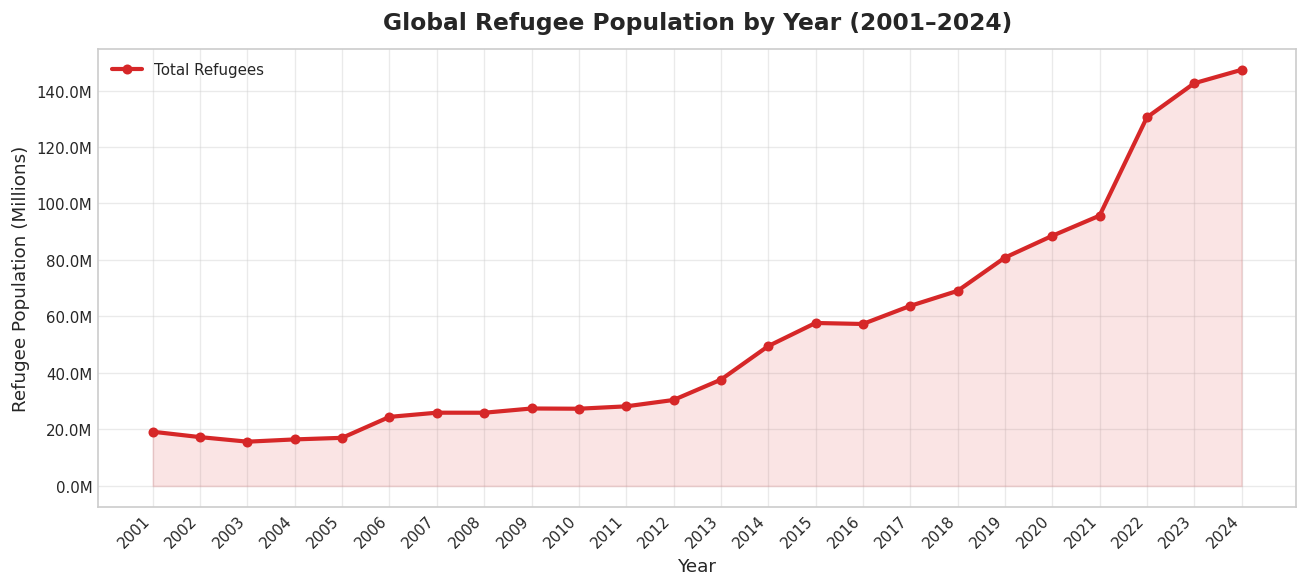

In [8]:
# ── Line Chart: Global Refugee Population Over Time ─────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(annual['year'], annual['total_refugees'] / 1e6,
        color=ACCENT, linewidth=2.5, marker='o', markersize=5, label='Total Refugees')
ax.fill_between(annual['year'], annual['total_refugees'] / 1e6, alpha=0.12, color=ACCENT)

ax.set_title('Global Refugee Population by Year (2001–2024)', fontsize=TITLE_SIZE, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=LABEL_SIZE)
ax.set_ylabel('Refugee Population (Millions)', fontsize=LABEL_SIZE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.set_xticks(annual['year'])
ax.set_xticklabels(annual['year'], rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretation:** The global refugee population follows a broadly upward trajectory 
over the 2001–2024 period, with a particularly steep acceleration from around 2011 
onwards coinciding with the onset of the Syrian Civil War. A second sharp rise is 
visible from 2022, driven primarily by the large-scale displacement caused by the 
Russian invasion of Ukraine. The period 2004–2010 shows relative stability, 
suggesting that geopolitical crises in that era generated displacement primarily 
on a regional rather than global scale. The overall increase from approximately 
20 million in the early 2000s to over 140 million by 2024 underscores the 
long-term structural growth in forced migration as a global humanitarian challenge.


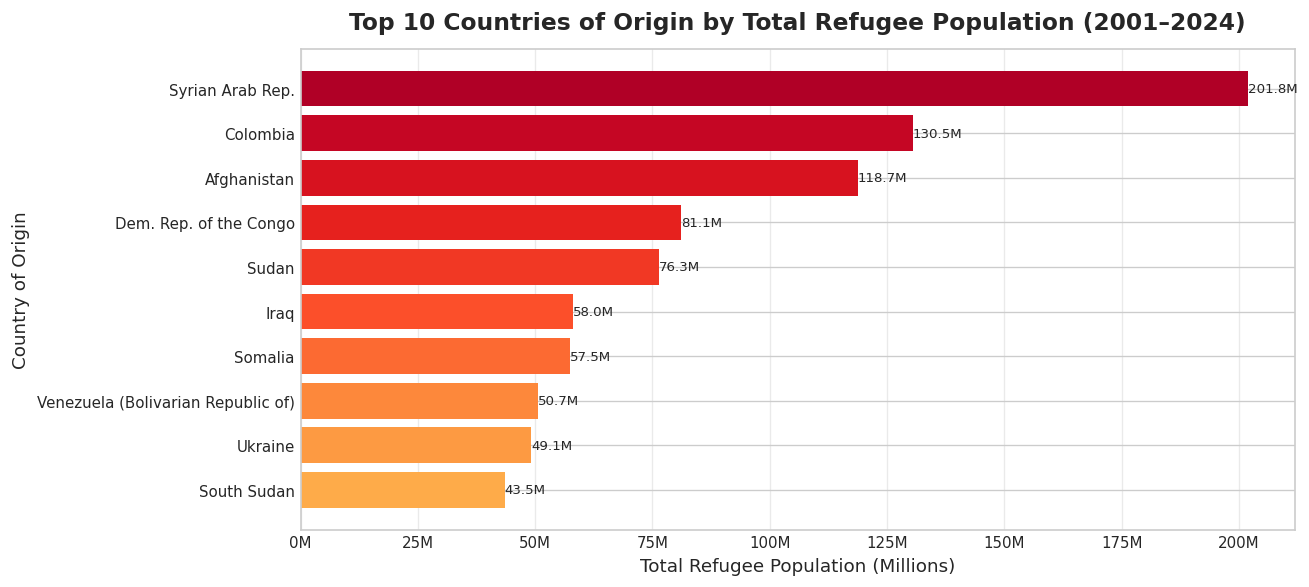

In [9]:
# ── Bar Chart: Top 10 Countries by Total Refugees (2001–2024) ───────────
top10_countries = (
    unhcr.groupby('country_of_origin')['total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10_countries.columns = ['country', 'total_refugees']

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.barh(top10_countries['country'][::-1],
               top10_countries['total_refugees'][::-1],
               color=plt.cm.YlOrRd(np.linspace(0.4, 0.9, 10)))

ax.set_title('Top 10 Countries of Origin by Total Refugee Population (2001–2024)',
             fontsize=TITLE_SIZE, fontweight='bold', pad=12)
ax.set_xlabel('Total Refugee Population (Millions)', fontsize=LABEL_SIZE)
ax.set_ylabel('Country of Origin', fontsize=LABEL_SIZE)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{width/1e6:.1f}M', va='center', fontsize=8)

ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretation:** The bar chart displays the **cumulative** total refugee 
population per country of origin across 2001–2024, not a single-year snapshot. 
**Syria** leads at 201.8M, reflecting consistent large-scale displacement since 
the 2011 civil war. **Colombia** (130.5M) and **Afghanistan** (118.7M) reflect 
decades of protracted conflict, while **Ukraine** (49.1M) stands out despite 
only generating significant displacement from 2022 onwards due to the scale 
of the Russian invasion. These cumulative figures should be read alongside 
single-year snapshots to understand both duration and peak intensity of 
each country's displacement crisis.

### 1.1.4  Choropleth Map - Refugee Population by Country of Origin (2004)

A choropleth map is produced for 2004 to establish a spatial baseline. 
The refugee data is aggregated by country of origin for 2004, then merged 
with world country geometries loaded from a local shapefile 
(`ne_110m_admin_0_countries.shp`) using ISO-3 country codes. The `YlOrRd` 
colour scale maps refugee population magnitude to colour intensity, making 
spatial hotspots immediately legible.


In [10]:
# ── Load World Geometry ──────────────────────────────────────────────────
world = gpd.read_file('data/ne_110m_admin_0_countries.shp')

# Retain only the columns needed for mapping
world_map = world[['ISO_A3', 'NAME', 'geometry']].copy()
world_map = world_map[world_map['ISO_A3'] != '-99']   # drop territories without ISO

print("World geometry loaded. Countries:", len(world_map))


World geometry loaded. Countries: 172


In [11]:
# ── Choropleth: Refugee Population 2004 ─────────────────────────────────

# Aggregate UNHCR data for 2004
unhcr_2004 = (
    unhcr[unhcr['year'] == 2004]
    .groupby('country_of_origin_iso')['total']
    .sum()
    .reset_index()
)
unhcr_2004.columns = ['ISO_A3', 'refugees']

# Merge with world geometry
world_2004 = world_map.merge(unhcr_2004, on='ISO_A3', how='left')

# Define a consistent vmax for fair 2004 vs 2024 comparison
# We compute it across both years
unhcr_2024_for_scale = (
    unhcr[unhcr['year'] == 2024]
    .groupby('country_of_origin_iso')['total']
    .sum()
)
vmax_global = max(unhcr_2004['refugees'].max(), unhcr_2024_for_scale.max())
vmax_global = int(np.ceil(vmax_global / 1e6) * 1e6)

print(f"2004 — Countries with refugee data: {unhcr_2004.shape[0]}")
print(f"Shared colour scale vmax: {vmax_global:,}")
print(f"Top 5 origin countries 2004:")
print(unhcr_2004.sort_values('refugees', ascending=False).head(5).to_string(index=False))


2004 — Countries with refugee data: 186
Shared colour scale vmax: 31,000,000
Top 5 origin countries 2004:
ISO_A3  refugees
   AFG   2691054
   COL   2095255
   SDN   1404883
   LBR    841619
   AZE    833080


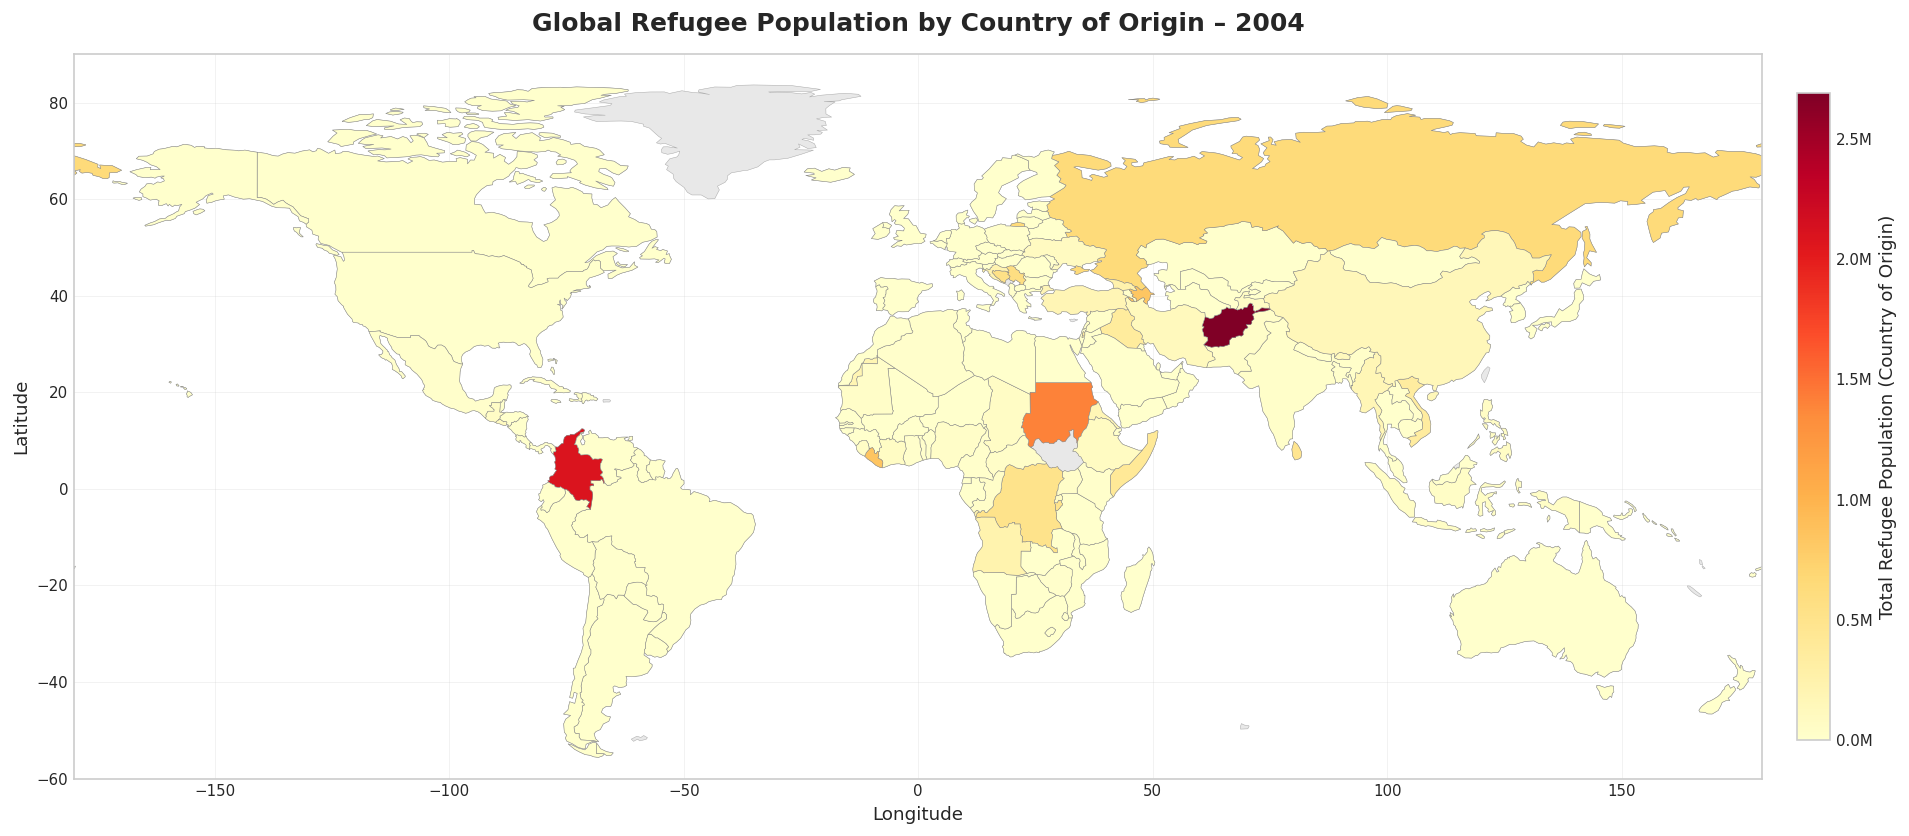

In [12]:
# ── Plot Choropleth 2004 ─────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

world_map.plot(ax=ax, color='#e8e8e8', edgecolor='#aaaaaa', linewidth=0.3)

# Use 2004's own vmax for better colour contrast
vmax_2004 = world_2004['refugees'].max()

world_2004.dropna(subset=['refugees']).plot(
    ax=ax,
    column='refugees',
    cmap=CMAP,
    vmin=0,
    vmax=vmax_2004,
    edgecolor='#888888',
    linewidth=0.3,
    legend=False
)

sm = ScalarMappable(cmap=CMAP, norm=Normalize(vmin=0, vmax=vmax_2004))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02, shrink=0.7)
cbar.set_label('Total Refugee Population (Country of Origin)', fontsize=LABEL_SIZE)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

ax.set_title('Global Refugee Population by Country of Origin – 2004',
             fontsize=TITLE_SIZE + 1, fontweight='bold', pad=14)
ax.set_xlabel('Longitude', fontsize=LABEL_SIZE)
ax.set_ylabel('Latitude', fontsize=LABEL_SIZE)
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 90)
ax.grid(True, alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()

**Interpretation:** The 2004 choropleth reveals a concentrated displacement 
pattern dominated by two major hotspots: **Afghanistan** and the broader 
Central Asian–Middle Eastern corridor (including Iraq), which together account 
for the vast majority of global refugee production in this period. **Colombia** 
stands out as a significant hotspot in South America, reflecting the peak of 
internal armed conflict with FARC during this period. African displacement is 
visible but comparatively diffuse, spread across several sub-Saharan countries 
including Sudan and the Democratic Republic of Congo, reflecting ongoing 
post-colonial conflicts. Europe shows minimal displacement at this time, while 
East Asia–Pacific contributes negligibly to the global refugee count. The 2004 
picture therefore represents a world where displacement is predominantly driven 
by unresolved post-Cold War conflicts concentrated in South Asia, the Middle 
East, and parts of Latin America.

 ### 1.1.5  Choropleth Map – Refugee Population by Country of Origin (2024)

The same methodology is applied for 2024 using **the same colour scale** as the 2004 map, enabling a direct visual comparison of how the global displacement landscape has shifted over two decades.


In [13]:
# ── Choropleth: Refugee Population 2024 ─────────────────────────────────

# Aggregate for 2024
unhcr_2024 = (
    unhcr[unhcr['year'] == 2024]
    .groupby('country_of_origin_iso')['total']
    .sum()
    .reset_index()
)
unhcr_2024.columns = ['ISO_A3', 'refugees']

world_2024 = world_map.merge(unhcr_2024, on='ISO_A3', how='left')

print(f"2024 — Countries with refugee data: {unhcr_2024.shape[0]}")
print(f"Top 5 origin countries 2024:")
print(unhcr_2024.sort_values('refugees', ascending=False).head(5).to_string(index=False))


2024 — Countries with refugee data: 207
Top 5 origin countries 2024:
ISO_A3  refugees
   SYR  30002976
   SDN  14371483
   AFG  10822549
   UKR   9706112
   VEN   8416439


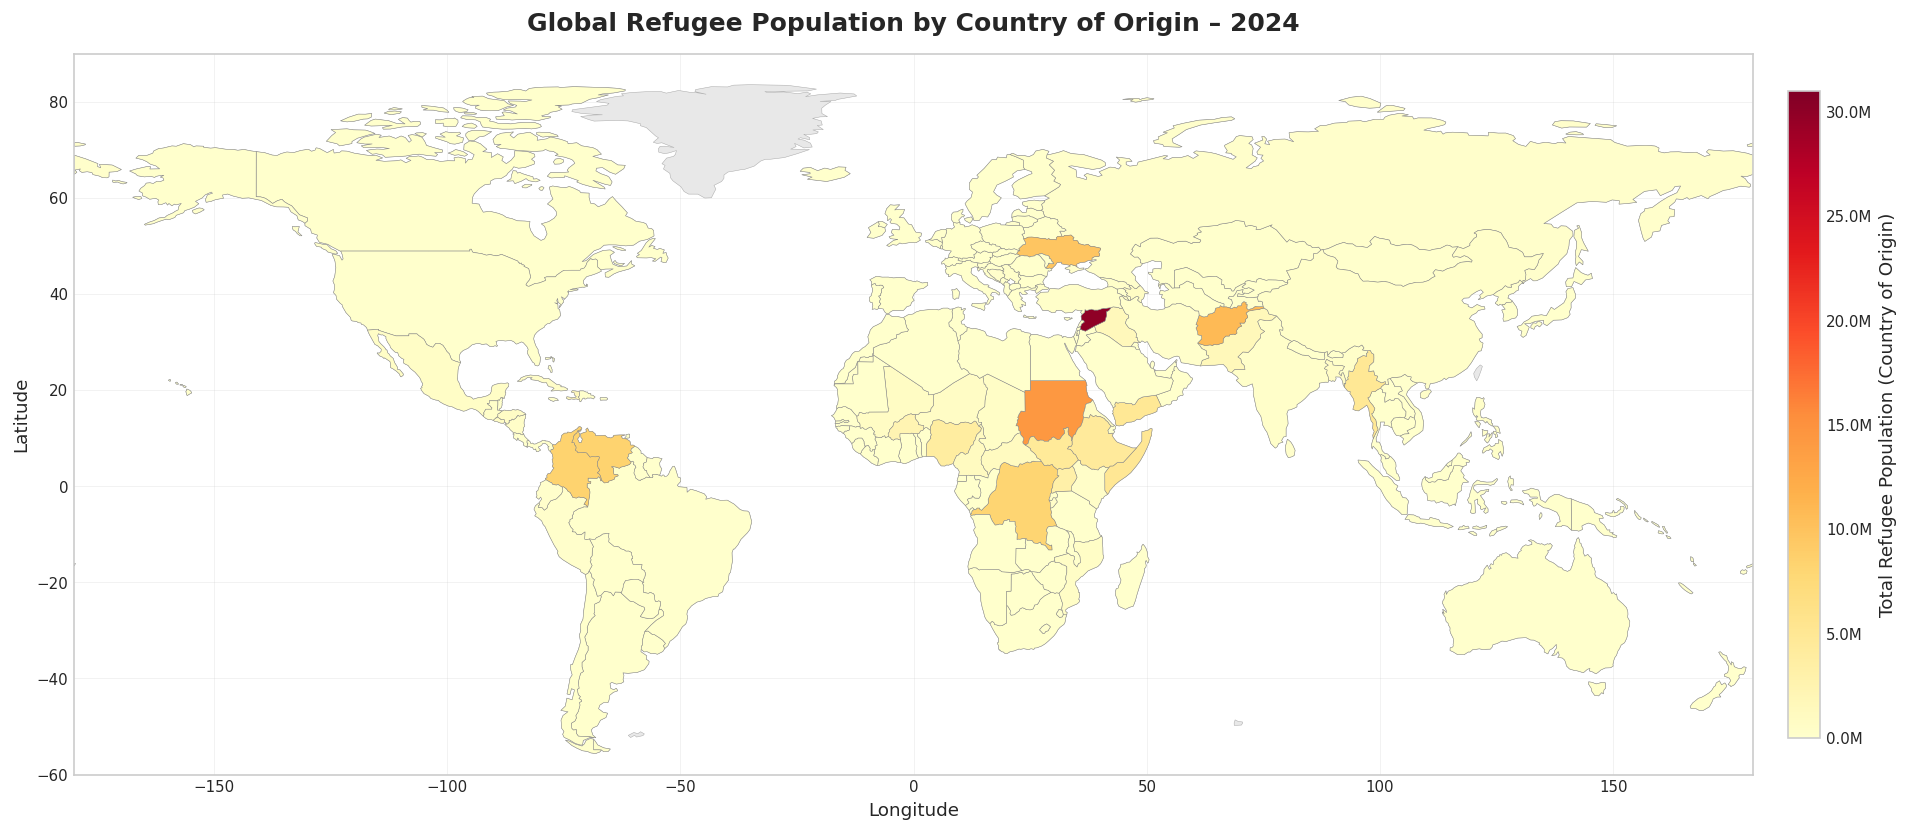

In [14]:
# ── Plot Choropleth 2024 (same vmax for comparability) ───────────────────
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

world_map.plot(ax=ax, color='#e8e8e8', edgecolor='#aaaaaa', linewidth=0.3)

world_2024.dropna(subset=['refugees']).plot(
    ax=ax,
    column='refugees',
    cmap=CMAP,
    vmin=0,
    vmax=vmax_global,
    edgecolor='#888888',
    linewidth=0.3,
    legend=False
)

sm = ScalarMappable(cmap=CMAP, norm=Normalize(vmin=0, vmax=vmax_global))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02, shrink=0.7)
cbar.set_label('Total Refugee Population (Country of Origin)', fontsize=LABEL_SIZE)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

ax.set_title('Global Refugee Population by Country of Origin – 2024',
             fontsize=TITLE_SIZE + 1, fontweight='bold', pad=14)
ax.set_xlabel('Longitude', fontsize=LABEL_SIZE)
ax.set_ylabel('Latitude', fontsize=LABEL_SIZE)
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 90)
ax.grid(True, alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.show()

**Interpretation (2004 vs 2024):** Comparing the 2024 map with the 2004 
baseline reveals a dramatic broadening of the global displacement crisis in 
both scale and geographic spread. **Syria** has emerged as the dominant 
hotspot, appearing as the darkest country on the map — a crisis that did not 
exist in 2004. **Sudan** shows a marked intensification, becoming one of the 
most prominent hotspots in Africa by 2024. **Afghanistan** remains a 
persistent high-intensity source across both time points. Sub-Saharan Africa 
shows broader darkening overall, with the DRC, South Sudan, and Ethiopia all 
exhibiting significantly higher displacement in 2024. **Colombia** remains 
visible in South America, though relatively lighter compared to 2004, 
suggesting some reduction in displacement intensity. The 2024 map illustrates 
that displacement is no longer concentrated in a small number of post-Cold War 
conflict zones but has become a geographically distributed global crisis, with 
multiple simultaneous crises driving humanitarian need across four continents.

## Task 1.2 – Combined Geospatial Analysis: Conflict and Refugee Data

This section integrates the UCDP Georeferenced Event Dataset (GED v25.1) 
with the UNHCR refugee data to examine the spatial relationship between 
armed conflict intensity and forced displacement. The UCDP GED records 
individual conflict events with precise geolocation and death estimates, 
enabling country-level and regional aggregation (Sundberg and Melander, 
2013; Davies et al., 2025).


![Conflict Zone](conflict.jpg)

### Load, Inspect and Clean the UCDP Conflict Dataset

The GED dataset is loaded with `low_memory=False` to handle mixed-type columns correctly. Key fields for this analysis include `country`, `year`, `region`, `latitude`, `longitude`, and `best` (best estimate of deaths). Each row represents a single conflict event.


In [ ]:
# Load UCDP GED dataset
conflict_raw = pd.read_csv('data/GEDEvent_v25_1.csv', low_memory=False)

print("Dataset shape:", conflict_raw.shape)
print()
print("Column names:")
print(conflict_raw.columns.tolist())
print()
print("Year range:", conflict_raw['year'].min(), "–", conflict_raw['year'].max())
print("Unique countries:", conflict_raw['country'].nunique())
print("Unique regions:", conflict_raw['region'].unique())
print()
conflict_raw[['country', 'year', 'region', 'latitude', 'longitude', 'best']].head(5)


### Exploratory Data Analysis – Conflict Dataset

Two summary visualisations provide a temporal and geographical overview of conflict activity: a **line chart** of total conflict events per year, and a **bar chart** of the top 10 countries by total events across the entire dataset period.


In [ ]:
# ── Conflict EDA ─────────────────────────────────────────────────────────

conflict = conflict_raw.copy()

# Events per year
events_per_year = conflict.groupby('year').size().reset_index(name='events')
print("Events per year (sample):")
print(events_per_year.tail(10).to_string(index=False))


In [ ]:
# ── Line Chart: Conflict Events Per Year ────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(events_per_year['year'], events_per_year['events'],
        color='#1f77b4', linewidth=2.5, marker='o', markersize=4, label='Conflict Events')
ax.fill_between(events_per_year['year'], events_per_year['events'], alpha=0.1, color='#1f77b4')

ax.set_title('Global Conflict Events Per Year (UCDP GED, 1989–2024)',
             fontsize=TITLE_SIZE, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=LABEL_SIZE)
ax.set_ylabel('Number of Conflict Events', fontsize=LABEL_SIZE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xticks(range(events_per_year['year'].min(), events_per_year['year'].max() + 1, 3))
ax.set_xticklabels(range(events_per_year['year'].min(), events_per_year['year'].max() + 1, 3), rotation=45)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


**Interpretation:** Conflict event frequency shows a broadly increasing 
long-run trend from 1989 to 2024. A modest rise is visible through the 
early 1990s, reflecting the Balkan wars and central African conflicts. 
The most dramatic escalation occurs around **2011–2014**, corresponding 
to the Syrian Civil War and the rapid expansion of the Islamic State across 
Iraq and Syria. A notable decline follows between **2016–2020**, before a 
sharp resurgence from **2021 onwards**, driven by the Ukraine conflict and 
a proliferation of sub-Saharan African conflicts, reaching the highest 
recorded event count in the dataset by 2024. The overall pattern confirms 
that armed conflict, far from being a declining phenomenon, has intensified 
over the 35-year period covered by the dataset.


In [ ]:
# ── Bar Chart: Top 10 Countries by Conflict Events (All Years) ──────────
top10_conflict = (
    conflict.groupby('country')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10_conflict.columns = ['country', 'events']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top10_conflict['country'][::-1],
               top10_conflict['events'][::-1],
               color=plt.cm.Blues(np.linspace(0.4, 0.85, 10)))

ax.set_title('Top 10 Countries by Total Conflict Events (UCDP GED, 1989–2024)',
             fontsize=TITLE_SIZE, fontweight='bold', pad=12)
ax.set_xlabel('Number of Conflict Events', fontsize=LABEL_SIZE)
ax.set_ylabel('Country', fontsize=LABEL_SIZE)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for bar in bars:
    width = bar.get_width()
    ax.text(width + 200, bar.get_y() + bar.get_height() / 2,
            f'{width:,.0f}', va='center', fontsize=8)

ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('fig_conflict_top10.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()


**Interpretation:** Syria ranks first by a considerable margin with 87,861 
events, reflecting the extraordinary scale and duration of the Syrian civil 
war. **Afghanistan** in second place (42,220) is consistent with its status 
as the world's longest-running modern conflict zone. **Ukraine's** third-place 
position (31,547), despite the conflict only beginning at scale from 2022, 
underlines the intensity and rapid escalation of the Russia–Ukraine war. 
The co-presence of **Mexico** (21,550) and **Colombia** (14,620) alongside 
conventional war zones highlights the growing relevance of organised criminal 
violence and cartel conflict, which the UCDP codes as non-state violence. 
**Bosnia-Herzegovina** (9,340) reflects the legacy of the 1990s Balkan wars, 
while **Myanmar (Burma)** (8,476) represents long-running ethnic insurgencies 
and military conflict in South-East Asia.

### Aggregate and Merge Datasets

Instead of a manual name-to-ISO dictionary, a **spatial join** is used here. 
Each conflict event carries precise `latitude` and `longitude` coordinates. 
These are converted to point geometries and spatially joined against the world 
country polygons from the same shapefile used for choropleth mapping — each 
event is assigned the `ISO_A3` code of the country polygon it falls inside. 
This is a genuinely geospatial merge: country membership is determined by 
*where the event occurred*, not by a text-label lookup.

After the spatial join, the merged ISO field is renamed for consistency, 
events are aggregated to country-year level, UNHCR refugee totals are 
similarly aggregated, and the two tables are joined on the shared `iso3 + 
year` key.

In [ ]:
# ── Step 1: Convert conflict events to a GeoDataFrame ────────────────────
# Each row becomes a point geometry using the event's lat/lon coordinates

conflict_gdf = gpd.GeoDataFrame(
    conflict[['id', 'year', 'country', 'region', 'best', 'latitude', 'longitude']].copy(),
    geometry=gpd.points_from_xy(conflict['longitude'], conflict['latitude']),
    crs='EPSG:4326'
)

print(f"Conflict GeoDataFrame shape : {conflict_gdf.shape}")
print(f"CRS: {conflict_gdf.crs}")
print(f"Sample geometry: {conflict_gdf.geometry.iloc[0]}")


In [ ]:
# ── Step 2: Spatial join — point-in-polygon against world shapefile ───────
# Each conflict event point is matched to the country polygon it falls within.
# how='left' keeps all events; predicate='within' tests point-in-polygon.

world_poly = world_map[['ISO_A3', 'NAME', 'geometry']].copy().to_crs('EPSG:4326')

conflict_spatial = gpd.sjoin(
    conflict_gdf,
    world_poly,
    how='left',
    predicate='within'
)

# Rename the joined ISO field
conflict_spatial = conflict_spatial.rename(columns={'ISO_A3': 'iso3', 'NAME': 'geo_country'})

# Report match quality
matched   = conflict_spatial['iso3'].notna().sum()
unmatched = conflict_spatial['iso3'].isna().sum()
print(f"Events matched to a country polygon : {matched:,}  ({matched/len(conflict_spatial)*100:.1f}%)")
print(f"Events unmatched (border/sea/NaN)   : {unmatched:,}  ({unmatched/len(conflict_spatial)*100:.1f}%)")
print()
print("Sample spatially-joined rows:")
conflict_spatial[['country', 'year', 'iso3', 'geo_country', 'latitude', 'longitude']].head(5)


**Interpretation:** The spatial join successfully matched **372,152 events 
(96.4%)** to a country polygon, with only 13,766 events (3.6%) unmatched — 
these represent events occurring on borders, at sea, or in disputed territories 
that fall outside any country polygon. The `ISO_A3` field from the shapefile 
was renamed to `iso3` and `NAME` to `geo_country` for consistency with the 
UNHCR dataset. The sample output confirms the join is working correctly, with 
Afghanistan events correctly assigned the ISO code `AFG`. The high match rate 
(96.4%) confirms the spatial join is reliable for subsequent country-level 
aggregation and merging with the UNHCR refugee data on the shared `iso3 + year` 
key.

In [ ]:
# ── Step 3: Aggregate conflict to country-year level ─────────────────────
conflict_agg = (
    conflict_spatial.dropna(subset=['iso3'])
    .groupby(['iso3', 'geo_country', 'year'])
    .agg(events=('id', 'count'), total_deaths=('best', 'sum'))
    .reset_index()
)

# Build a reusable iso3 -> display name lookup from the spatial join result
iso_to_name = (
    conflict_spatial[['iso3', 'geo_country']]
    .dropna()
    .drop_duplicates('iso3')
    .set_index('iso3')['geo_country']
    .to_dict()
)

print(f"Conflict aggregated: {conflict_agg.shape[0]} country-year records")
print(f"Unique countries after spatial join: {conflict_agg['iso3'].nunique()}")

# ── Step 4: Aggregate UNHCR refugees to country-year level
unhcr_agg = (
    unhcr.groupby(['country_of_origin_iso', 'country_of_origin', 'year'])
    .agg(refugees=('total', 'sum'),
         female_refugees=('female_total', 'sum'),
         children_0_4=('children_0_4', 'sum'))
    .reset_index()
    .rename(columns={'country_of_origin_iso': 'iso3', 'country_of_origin': 'origin_country'})
)

print(f"UNHCR aggregated   : {unhcr_agg.shape[0]} country-year records")

# ── Step 5: Pandas join (Inner join) on iso3 + year 
merged = conflict_agg.merge(unhcr_agg, on=['iso3', 'year'], how='inner')

print(f"\nMerged dataset shape: {merged.shape}")
print(f"Year range in merged: {merged['year'].min()} - {merged['year'].max()}")
print()
print("Sample rows:")
merged[['geo_country', 'year', 'events', 'total_deaths', 'refugees']].head(8)


**Interpretation:** The merged dataset contains **1,421 country-year records** 
across 9 columns, covering **2001–2024**. The conflict data contributed 2,218 
country-year records across 130 unique countries after the spatial join, while 
the UNHCR data contributed 4,661 country-year records. The inner join on 
`iso3 + year` retains only records where both conflict and refugee data exist 
for the same country and year, resulting in 1,421 matched records. The sample 
output confirms the merge is correct, Afghanistan shows yearly conflict events 
and refugee totals side by side, with events peaking at 1,041 in 2007 while 
refugee numbers fluctuate between approximately 2.3M and 5.1M across the period.

In [ ]:
# Verify Middle East countries in merged dataset
print("=== MIDDLE EAST VERIFICATION ===")

# Check what Middle East countries exist in conflict data
me_iso_standard = ['IRQ', 'IRN', 'SAU', 'SYR', 'PSE', 'ISR', 'JOR', 'LBN', 'KWT', 'QAT', 'YEM', 'ARE', 'OMN', 'BHR']

# Check which ones exist in conflict data
in_conflict = conflict_agg[conflict_agg['iso3'].isin(me_iso_standard)]['iso3'].unique()
in_unhcr = unhcr_agg[unhcr_agg['iso3'].isin(me_iso_standard)]['iso3'].unique()
in_merged = merged[merged['iso3'].isin(me_iso_standard)]['iso3'].unique()

print(f"\nMiddle East countries defined:     {len(me_iso_standard)}")
print(f"Found in conflict data:            {sorted(in_conflict)}")
print(f"Found in UNHCR data:               {sorted(in_unhcr)}")
print(f"Found in merged dataset:           {sorted(in_merged)}")

# Check which ones are MISSING
missing_conflict = set(me_iso_standard) - set(in_conflict)
missing_unhcr = set(me_iso_standard) - set(in_unhcr)
missing_merged = set(me_iso_standard) - set(in_merged)

print(f"\nMissing from conflict data:        {missing_conflict}")
print(f"Missing from UNHCR data:           {missing_unhcr}")
print(f"Missing from merged (both needed): {missing_merged}")

# Show country names for merged ones
print("\nFull names of matched Middle East countries:")
for iso in sorted(in_merged):
    name = iso_to_name.get(iso, 'Unknown')
    print(f"  {iso} → {name}")

### Task 1.2.1 – Refugee Population (2024) for High-Conflict Countries > 5000 conflicts
Countries with **more than 5,000 conflict events since 2000** are identified as high-conflict states. The 2024 refugee population is then mapped for these countries only, revealing the scale of displacement associated with sustained armed conflict.


In [ ]:
# ── Identify high-conflict countries (>5000 events since 2000) ───────────
# Use the spatially-joined conflict_spatial, which has iso3 from the point-in-polygon join
high_conflict_iso = (
    conflict_spatial[conflict_spatial['year'] >= 2000]
    .dropna(subset=['iso3'])
    .groupby('iso3')
    .size()
    .reset_index(name='events_since_2000')
    .query('events_since_2000 > 5000')
)

print(f"High-conflict countries (>5000 events since 2000): {len(high_conflict_iso)}")
print(high_conflict_iso.sort_values('events_since_2000', ascending=False).to_string(index=False))


In [ ]:
# ── Refugee population 2024 for high-conflict countries ──────────────────
ref_2024 = unhcr[unhcr['year'] == 2024].groupby('country_of_origin_iso')['total'].sum().reset_index()
ref_2024.columns = ['ISO_A3', 'refugees']

# Keep only high-conflict ISOs
hc_isos = set(high_conflict_iso['iso3'].dropna())
ref_2024_hc = ref_2024[ref_2024['ISO_A3'].isin(hc_isos)]

# Merge with world geometry
world_hc = world_map.copy()
world_hc['refugees'] = world_hc['ISO_A3'].map(ref_2024_hc.set_index('ISO_A3')['refugees'])

print("High-conflict countries matched to refugee data:")
print(ref_2024_hc.sort_values('refugees', ascending=False).to_string(index=False))


In [ ]:
# ── Plot Choropleth: 2024 Refugees in High-Conflict Countries ────────────
fig, ax = plt.subplots(figsize=(16, 8))

# Base world in grey
world_map.plot(ax=ax, color='#e8e8e8', edgecolor='#aaaaaa', linewidth=0.3)

# Highlight high-conflict countries with refugee choropleth
world_hc.dropna(subset=['refugees']).plot(
    ax=ax, column='refugees', cmap=CMAP,
    vmin=0, edgecolor='#555555', linewidth=0.5, legend=False
)

# Outline all high-conflict countries (including those with near-zero refugees)
world_hc[world_hc['ISO_A3'].isin(hc_isos)].plot(
    ax=ax, color='none', edgecolor='#333333', linewidth=1.2
)

sm = ScalarMappable(cmap=CMAP, norm=Normalize(vmin=0, vmax=world_hc['refugees'].max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02, shrink=0.7)
cbar.set_label('Refugee Population (Country of Origin, 2024)', fontsize=LABEL_SIZE)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

ax.set_title('2024 Refugee Population for Countries with >5,000 Conflict Events Since 2000',
             fontsize=TITLE_SIZE, fontweight='bold', pad=14)
ax.set_xlabel('Longitude', fontsize=LABEL_SIZE)
ax.set_ylabel('Latitude', fontsize=LABEL_SIZE)
ax.set_xlim(-180, 180); ax.set_ylim(-60, 90)
ax.grid(True, alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()

**Interpretation:** The choropleth clearly demonstrates a strong spatial 
co-occurrence between sustained conflict intensity and large refugee populations 
in 2024. **Syria** stands out as the dominant producer of refugees among 
high-conflict states, exhibiting maximum colour saturation on the map. 
**Afghanistan** similarly shows deep colouring, reflecting decades of 
continuous conflict. **Ukraine**, despite only recently joining the 
high-conflict group, already generates a substantial refugee population, 
reflecting the speed at which large-scale conventional warfare can displace 
millions. **Brazil**, **Mexico**, and **Colombia** appear as notable 
highlighted countries in the Americas, reflecting the UCDP classification 
of organised criminal and cartel violence. **Myanmar** and the **DRC** show 
moderate-to-high refugee counts, consistent with their protracted insurgencies. 
The pattern affirms that conflict is a primary structural driver of forced 
displacement, with refugee magnitude broadly proportional to the duration 
and intensity of violence.

### Task 1.2.2 – Conflict Events in Middle East Countries with female refugee > 50,000 in 2024

This analysis focuses on the **Middle East region** as defined in the UCDP dataset and filters for countries where the total female refugee population in 2024 exceeded 50,000. A choropleth maps total conflict events in 2024 for those countries, providing a gendered lens on displacement geography.


In [ ]:
# ── Middle East ISO codes — derived from the spatial join ────────────────
# The spatial join already assigned each event an ISO_A3. We filter by the
# UCDP 'region' field (which labels events, not countries) and collect the
# unique iso3 values that fall in the Middle East region.

# Standard geographic definition of Middle East
me_iso = ['IRQ', 'IRN', 'SAU', 'SYR', 'PSE', 'ISR', 
          'JOR', 'LBN', 'KWT', 'QAT', 'YEM', 'ARE', 'OMN', 'BHR']

print(f"Middle East countries (standard definition): {len(me_iso)}")
print(me_iso)


In [ ]:
# ── Female refugees in 2024 for Middle East countries ───────────────────
female_2024 = (
    unhcr[unhcr['year'] == 2024]
    .groupby('country_of_origin_iso')['female_total']
    .sum()
    .reset_index()
)
female_2024.columns = ['iso3', 'female_refugees_2024']

# Filter: Middle East AND female refugees > 50,000
me_female = female_2024[
    (female_2024['iso3'].isin(me_iso)) &
    (female_2024['female_refugees_2024'] > 50_000)
]

print("Middle East countries with female refugees > 50,000 in 2024:")
print(me_female.sort_values('female_refugees_2024', ascending=False).to_string(index=False))


In [ ]:
# ── Conflict events in 2024 for those countries ──────────────────────────
# Use conflict_spatial (spatially-joined) so iso3 is consistent
conflict_2024 = (
    conflict_spatial[conflict_spatial['year'] == 2024]
    .dropna(subset=['iso3'])
    .groupby('iso3')
    .size()
    .reset_index(name='events_2024')
)

target_isos = set(me_female['iso3'].dropna())

# Build map dataframe
world_me = world_map.copy()
world_me['events_2024'] = world_me['ISO_A3'].map(
    conflict_2024.set_index('iso3')['events_2024']
)
# Zero out non-target countries
world_me.loc[~world_me['ISO_A3'].isin(target_isos), 'events_2024'] = np.nan

print("2024 conflict events for qualifying Meddle East countries:")
conflict_2024[conflict_2024['iso3'].isin(target_isos)].sort_values('events_2024', ascending=False)


In [ ]:
# ── Plot: Conflict Events in Middle East High-Female-Refugee Countries ────
fig, ax = plt.subplots(figsize=(14, 7))

world_map.plot(ax=ax, color='#e8e8e8', edgecolor='#aaaaaa', linewidth=0.3)

world_me.dropna(subset=['events_2024']).plot(
    ax=ax, column='events_2024', cmap='PuRd',
    vmin=0, edgecolor='#444444', linewidth=0.6, legend=False
)

# Outline target countries
world_me[world_me['ISO_A3'].isin(target_isos)].plot(
    ax=ax, color='none', edgecolor='#222222', linewidth=1.3
)

# Label qualifying countries
for _, row in world_me[world_me['ISO_A3'].isin(target_isos)].iterrows():
    if row.geometry and not row.geometry.is_empty:
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.annotate(row['NAME'], xy=(cx, cy), fontsize=7.5,
                    ha='center', color='#111111',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

sm = ScalarMappable(cmap='PuRd', norm=Normalize(vmin=0, vmax=world_me['events_2024'].max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02, shrink=0.7)
cbar.set_label('Conflict Events in 2024', fontsize=LABEL_SIZE)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax.set_title('Middle East: Conflict Events (2024) in Countries with\n>50,000 Female Refugees (2024)',
             fontsize=TITLE_SIZE, fontweight='bold', pad=14)
ax.set_xlabel('Longitude', fontsize=LABEL_SIZE)
ax.set_ylabel('Latitude', fontsize=LABEL_SIZE)
ax.set_xlim(20, 70); ax.set_ylim(10, 45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation:** The map highlights that within the Middle East, the 
countries combining active conflict in 2024 with large female refugee 
populations are primarily **Syria**, **Iraq**, and **Iran**. **Syria** 
shows the darkest shading, reflecting its exceptionally high conflict 
event count and over a decade of civil war that has systematically 
displaced entire family units across borders into Turkey, Lebanon, and 
Jordan. **Iraq** shows moderate conflict intensity, reflecting ongoing 
insurgency and instability following decades of armed conflict. **Iran** 
qualifies due to its large female refugee population despite comparatively 
lower direct conflict events in 2024. The gender dimension is significant — 
female refugees frequently face compounded vulnerabilities including limited 
access to legal documentation, heightened risk of gender-based violence, 
and reduced economic agency, issues that are structurally amplified in 
conflict-affected states across the Middle East.

### Task 1.2.3 – Top 5 Countries: Child Refugees (Age 0–4) and Conflict trends 2004 - 2024
Children aged 0–4 represent one of the most vulnerable groups in displacement contexts. This analysis identifies the **top 5 countries of origin** by total child (age 0–4) refugee population over 2004–2024, then plots both child refugee trends and corresponding conflict event trends for those countries on a dual-panel figure.


In [ ]:
# ── Top 5 countries by total child refugees (age 0-4), 2004-2024 ─────────
child_data = unhcr[(unhcr['year'] >= 2004) & (unhcr['year'] <= 2024)].copy()

top5_child = (
    child_data.groupby(['country_of_origin_iso', 'country_of_origin'])['children_0_4']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
top5_child.columns = ['iso3', 'country', 'total_children_0_4']
print("Top 5 countries by child refugees (age 0-4), 2004–2024:")
print(top5_child.to_string(index=False))


In [ ]:
# ── Time-series data for the top 5 countries ────────────────────────────
top5_isos = top5_child['iso3'].tolist()

# Child refugees per year per country
child_ts = (
    child_data[child_data['country_of_origin_iso'].isin(top5_isos)]
    .groupby(['country_of_origin_iso', 'country_of_origin', 'year'])['children_0_4']
    .sum()
    .reset_index()
)

# Conflict events per year per country (2004-2024)
# Use conflict_spatial (spatially-joined); iso_to_name was built from the spatial join
top5_conflict_names = [iso_to_name.get(i, i) for i in top5_isos]
print("Display names for top 5 countries (from spatial join):", top5_conflict_names)

conflict_ts = (
    conflict_spatial[
        (conflict_spatial['iso3'].isin(top5_isos)) &
        (conflict_spatial['year'] >= 2004) &
        (conflict_spatial['year'] <= 2024)
    ]
    .dropna(subset=['iso3'])
    .groupby(['iso3', 'year'])
    .size()
    .reset_index(name='events')
)


In [ ]:
# ── Dual-panel Figure: Child Refugees + Conflict Events ──────────────────
palette = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3']
country_color = dict(zip(top5_isos, palette))

fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

# Panel 1: Child refugee trend
ax1 = axes[0]
for iso, row in top5_child.iterrows():
    subset = child_ts[child_ts['country_of_origin_iso'] == row['iso3']]
    if subset.empty:
        continue
    ax1.plot(subset['year'], subset['children_0_4'] / 1e3,
             color=country_color[row['iso3']], linewidth=2.2, marker='o', markersize=4,
             label=row['country'])

ax1.set_title('Child Refugees (Age 0–4) by Country of Origin (2004–2024)',
              fontsize=TITLE_SIZE, fontweight='bold')
ax1.set_ylabel("Children Aged 0–4 (Thousands)", fontsize=LABEL_SIZE)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax1.legend(loc='upper left', framealpha=0.85)
ax1.grid(True, alpha=0.4)

# Panel 2: Conflict events
ax2 = axes[1]
for iso in top5_isos:
    subset = conflict_ts[conflict_ts['iso3'] == iso]
    if subset.empty:
        # Plot zero line if no data
        country_name = child_ts[child_ts['country_of_origin_iso'] == iso]['country_of_origin'].iloc[0]                        if len(child_ts[child_ts['country_of_origin_iso'] == iso]) > 0 else iso
        ax2.plot([], [], color=country_color[iso], linewidth=2.2, label=country_name)
        continue
    country_name = child_ts[child_ts['country_of_origin_iso'] == iso]['country_of_origin'].iloc[0]
    ax2.plot(subset['year'], subset['events'],
             color=country_color[iso], linewidth=2.2, marker='s', markersize=4,
             label=country_name)

ax2.set_title('Total Conflict Events by Country (2004–2024)',
              fontsize=TITLE_SIZE, fontweight='bold')
ax2.set_xlabel('Year', fontsize=LABEL_SIZE)
ax2.set_ylabel('Conflict Events', fontsize=LABEL_SIZE)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.set_xticks(range(2004, 2025, 2))
ax2.set_xticklabels(range(2004, 2025, 2), rotation=45)
ax2.legend(loc='upper left', framealpha=0.85)
ax2.grid(True, alpha=0.4)

plt.suptitle('Child Displacement (Age 0–4) and Conflict Intensity: Top 5 Origin Countries',
             fontsize=TITLE_SIZE + 1, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** The dual-panel figure reveals a compelling narrative 
across the top five child-refugee-producing countries. **Syria** dominates 
the upper panel, showing the most dramatic spike in children aged 0-4 from 
2011 onwards, directly corresponding to the sharp escalation in conflict 
events visible in the lower panel. **Somalia** shows consistently high child 
displacement throughout the period, reflecting decades of protracted conflict 
with relatively steady conflict event counts. **Afghanistan** shows a 
secondary rise in child refugees after 2021, consistent with the Taliban 
takeover and renewed displacement. **DRC** and **Sudan** both show irregular 
but recurring surges tied to specific conflict episodes in the lower panel. 
The data reinforces that children aged 0-4 — born into or during active 
conflict — face an acute risk of displacement, and that the humanitarian 
burden of child refugees falls disproportionately on a small number of 
persistently conflict-affected states.

### Task 1.2.4 – Percentage Change in Refugee Population for the Highest-Conflict Country (2004–2024)

The country with the **highest total conflict events** across the full UCDP dataset is identified. For that country, the year-by-year refugee population from 2004 to 2024 is calculated, and the percentage change relative to the 2004 baseline is plotted. A horizontal reference line at 0% allows the direction of change to be read immediately.


In [ ]:
# ── Identify country with highest total conflict events ──────────────────
# Use conflict_spatial so the iso3 comes from the spatial join, not a lookup dict

top_conflict_iso = (
    conflict_spatial.dropna(subset=['iso3'])
    .groupby('iso3')
    .size()
    .idxmax()
)
top_conflict_country_name = iso_to_name.get(top_conflict_iso, top_conflict_iso)

total_events = conflict_spatial[conflict_spatial['iso3'] == top_conflict_iso].shape[0]
print(f"Country with most conflict events : {top_conflict_country_name}")
print(f"ISO-3 code (from spatial join)    : {top_conflict_iso}")
print(f"Total events                      : {total_events:,}")


In [ ]:
# ── Year-by-year refugees for top conflict country, 2004-2024 ────────────
top_unhcr = (
    unhcr[
        (unhcr['country_of_origin_iso'] == top_conflict_iso) &
        (unhcr['year'] >= 2004) &
        (unhcr['year'] <= 2024)
    ]
    .groupby('year')['total']
    .sum()
    .reset_index()
)
top_unhcr.columns = ['year', 'refugees']

# Baseline = 2004 value
baseline_2004 = top_unhcr.loc[top_unhcr['year'] == 2004, 'refugees'].values
if len(baseline_2004) == 0 or baseline_2004[0] == 0:
    # If 2004 is missing or zero, use minimum year available or first non-zero year
    baseline_2004 = top_unhcr[top_unhcr['refugees'] > 0]['refugees'].iloc[0]
    baseline_year = top_unhcr[top_unhcr['refugees'] > 0]['year'].iloc[0]
else:
    baseline_2004 = baseline_2004[0]
    baseline_year = 2004

top_unhcr['pct_change'] = ((top_unhcr['refugees'] - baseline_2004) / baseline_2004) * 100

print(f"Baseline ({baseline_year}) refugee population: {baseline_2004:,}")
print()
print("Year-by-year data:")
print(top_unhcr.to_string(index=False))


In [ ]:
# ── Calculate year-on-year percentage change ─────────────────────────────
top_unhcr = top_unhcr.sort_values('year').reset_index(drop=True)
top_unhcr['yoy_change'] = top_unhcr['refugees'].pct_change() * 100

fig, ax = plt.subplots(figsize=(12, 6))

# Line connecting points
ax.plot(top_unhcr['year'], top_unhcr['yoy_change'],
        color=ACCENT, linewidth=1.5, zorder=1)

# Scatter points coloured by increase/decrease
colors = top_unhcr['yoy_change'].apply(
    lambda x: ACCENT if x >= 0 else '#4575b4'
)
ax.scatter(top_unhcr['year'], top_unhcr['yoy_change'],
           c=colors, s=80, zorder=2,
           label='Year-on-Year % Change')

# Reference line at 0%
ax.axhline(y=0, color='black', linewidth=1.4,
           linestyle='--', alpha=0.7, label='No Change (0%)')

# Annotate peak
max_row = top_unhcr.dropna().loc[top_unhcr['yoy_change'].idxmax()]
ax.annotate(f"Peak: +{max_row['yoy_change']:.0f}% ({int(max_row['year'])})",
            xy=(max_row['year'], max_row['yoy_change']),
            xytext=(max_row['year'] + 1, max_row['yoy_change'] * 0.85),
            fontsize=9, color=ACCENT,
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.2))

# Annotate negative points explicitly
for _, row in top_unhcr.dropna().iterrows():
    if row['yoy_change'] < 0:
        ax.annotate(f"{row['yoy_change']:.0f}%",
                    xy=(row['year'], row['yoy_change']),
                    xytext=(0, -15), textcoords='offset points',
                    fontsize=7.5, color='#4575b4', ha='center')

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=ACCENT,
           markersize=9, label='Increase'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4575b4',
           markersize=9, label='Decrease'),
    Line2D([0], [0], color='black', linewidth=1.4,
           linestyle='--', label='No Change (0%)')
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_title(f'Year-on-Year % Change in Refugee Population: {top_conflict_country_name} (2004–2024)',
             fontsize=TITLE_SIZE, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=LABEL_SIZE)
ax.set_ylabel('Year-on-Year Change (%)', fontsize=LABEL_SIZE)
ax.set_xticks(top_unhcr['year'])
ax.set_xticklabels(top_unhcr['year'].astype(int), rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Interpretation:** Syria, the country with the highest total UCDP conflict 
event count, illustrates how a sudden onset of civil war produces an explosive 
and highly concentrated spike in refugee generation. The year-on-year percentage 
change is near-zero from 2004 to 2010, reflecting Syria's pre-conflict stability 
when refugee outflows were negligible. The dramatic peak of **+5,631% in 2012** 
represents the single most intense year of refugee generation, as the Assad 
government's violent crackdown escalated into full-scale civil war, triggering 
mass exodus across borders into Turkey, Lebanon, and Jordan almost overnight. 
Three years show negative values **-7% (2005)**, **-15% (2006)**, and 
**-3% (2022)** the first two reflecting minor pre-conflict fluctuations, 
while the 2022 dip likely reflects modest repatriation efforts or reclassification 
of displaced persons. Following the 2012 peak, the rate of change drops sharply 
back towards zero, not because displacement stopped, but because the refugee 
population had already reached a large base, making further percentage increases 
smaller even as absolute numbers continued to grow. Year-on-year percentage 
change must therefore always be read alongside absolute population figures to 
avoid underestimating the continued humanitarian burden of protracted conflict.

###  Task 1.2.5 – 1,000 km Buffer Around the Highest-Conflict Country Since 2010 (Neighbouring Refugee Populations)

This task identifies the country with the **most conflict events since 2010** (rather than all-time), constructs a **1,000 km buffer** around its geometric centroid, and analyses the 2024 refugee populations of all countries whose centroids fall within that buffer. The analysis tests whether geographic proximity to a high-conflict state is associated with elevated refugee populations, a key question in humanitarian spatial planning.

In [ ]:
# ── Identify country with most conflict events since 2010 ─────────────────
top10_iso = (
    conflict_spatial[conflict_spatial['year'] >= 2010]
    .dropna(subset=['iso3'])
    .groupby('iso3')
    .size()
    .idxmax()
)
top10_name = iso_to_name.get(top10_iso, top10_iso)
total10 = conflict_spatial[
    (conflict_spatial['year'] >= 2010) &
    (conflict_spatial['iso3'] == top10_iso)
].shape[0]

print(f"Highest-conflict country since 2010 : {top10_name}")
print(f"ISO-3 code                          : {top10_iso}")
print(f"Conflict events 2010–present        : {total10:,}")

# Top 10 for context
top10_list = (
    conflict_spatial[conflict_spatial['year'] >= 2010]
    .dropna(subset=['iso3'])
    .groupby('iso3').size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10_list.columns = ['iso3', 'events']
top10_list['country'] = top10_list['iso3'].map(iso_to_name)
print()
print("Top 10 countries by conflict events since 2010:")
print(top10_list.to_string(index=False))

In [ ]:
# ── Build centroid and 1000 km buffer ────────────────────────────────────
# Step 1: isolate the polygon(s) for the target country
target_geom = world_map[world_map['ISO_A3'] == top10_iso].copy()

# Step 2: project to Web Mercator (metres) so buffer distance is accurate
target_merc = target_geom.to_crs('EPSG:3857')
centroid_merc = target_merc.geometry.centroid.iloc[0]

# Step 3: create the 1000 km buffer in projected CRS, convert back to WGS-84
buf_merc = centroid_merc.buffer(1_000_000)           # 1 000 000 m = 1 000 km
import geopandas as gpd
from shapely.geometry import shape
buf_gdf_merc = gpd.GeoDataFrame(geometry=[buf_merc], crs='EPSG:3857')
buf_gdf = buf_gdf_merc.to_crs('EPSG:4326')
centroid_wgs = target_geom.geometry.centroid.iloc[0]

print(f"Target country  : {top10_name}")
print(f"Centroid (WGS-84): lon={centroid_wgs.x:.2f}, lat={centroid_wgs.y:.2f}")
print(f"Buffer CRS       : EPSG:3857  →  reprojected to EPSG:4326")
print(f"Buffer radius    : 1,000 km")

# Step 4: find all countries whose centroids fall inside the buffer
world_map_copy = world_map.copy()
world_map_copy['centroid'] = world_map_copy.geometry.centroid

world_wgs = world_map_copy.to_crs('EPSG:4326')
buf_geom = buf_gdf.geometry.iloc[0]

neighbours = world_map_copy[
    (world_map_copy['ISO_A3'] != top10_iso) &
    world_map_copy['centroid'].within(buf_geom)
].copy()

print(f"Countries with centroids within 1,000 km buffer: {len(neighbours)}")
print(neighbours[['ISO_A3', 'NAME']].to_string(index=False))

In [ ]:
# ── Get 2024 refugee populations and centroid distances ──────────────────
import numpy as np

# 2024 refugee totals per origin country
ref2024 = (
    unhcr[unhcr['year'] == 2024]
    .groupby('country_of_origin_iso')['total']
    .sum()
    .reset_index()
)
ref2024.columns = ['ISO_A3', 'refugees_2024']

neighbours = neighbours.merge(ref2024, on='ISO_A3', how='left')
neighbours['refugees_2024'] = neighbours['refugees_2024'].fillna(0)

# Haversine distance from each neighbour centroid to conflict-country centroid
def haversine(lon1, lat1, lon2, lat2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

neighbours['dist_km'] = neighbours['centroid'].apply(
    lambda p: haversine(centroid_wgs.x, centroid_wgs.y, p.x, p.y)
)

display_cols = ['NAME', 'ISO_A3', 'dist_km', 'refugees_2024']
print("Neighbouring countries — distance and 2024 refugee population:")
print(
    neighbours[display_cols]
    .sort_values('dist_km')
    .rename(columns={'NAME':'Country','ISO_A3':'ISO3',
                     'dist_km':'Distance (km)','refugees_2024':'Refugees 2024'})
    .to_string(index=False, float_format=lambda x: f'{x:,.0f}')
)

In [ ]:
# ── Map: Buffer, Conflict Country and Neighbour Refugee Populations ───────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(14, 9))

# 1. Grey world base
world_map.plot(ax=ax, color='#e8e8e8', edgecolor='#aaaaaa', linewidth=0.3)

# 2. Neighbour countries coloured by refugee population
vmax_buf = neighbours['refugees_2024'].max()
if vmax_buf == 0:
    vmax_buf = 1  # avoid div-by-zero
neighbours.plot(
    ax=ax, column='refugees_2024', cmap='YlOrRd',
    vmin=0, vmax=vmax_buf, edgecolor='#555555', linewidth=0.6, legend=False
)

# 3. Buffer circle outline
buf_gdf.boundary.plot(ax=ax, edgecolor='#1a6b9e', linewidth=2.0, linestyle='--', label='1,000 km Buffer')
buf_gdf.plot(ax=ax, color='#1a6b9e', alpha=0.07)

# 4. Highlight the central conflict country in red
world_map[world_map['ISO_A3'] == top10_iso].plot(
    ax=ax, color=ACCENT, edgecolor='#333333', linewidth=1.0, label=f'{top10_name} (Highest Conflict since 2010)'
)

# 5. Centroid marker
ax.scatter(centroid_wgs.x, centroid_wgs.y, s=120, color='black',
           marker='*', zorder=6, label='Centroid')

# 6. Distance labels on neighbour centroids
for _, row in neighbours.iterrows():
    cx, cy = row['centroid'].x, row['centroid'].y
    ax.annotate(
        f"{row['dist_km']:.0f} km",
        xy=(cx, cy), fontsize=6.5, ha='center', va='bottom',
        color='#333333',
        bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.55, lw=0)
    )

# 7. Colorbar
sm = ScalarMappable(cmap='YlOrRd', norm=Normalize(vmin=0, vmax=vmax_buf))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.025, pad=0.02, shrink=0.65)
cbar.set_label('Refugee Population (Country of Origin, 2024)', fontsize=LABEL_SIZE)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x):,}'))

ax.set_title(
    f'1,000 km Buffer Around {top10_name} — Neighbouring Countries\n'
    f'Coloured by 2024 Refugee Population (Conflict Events Since 2010)',
    fontsize=TITLE_SIZE, fontweight='bold', pad=12
)
ax.set_xlabel('Longitude', fontsize=LABEL_SIZE)
ax.set_ylabel('Latitude', fontsize=LABEL_SIZE)

# Dynamic map extent: buffer bbox + padding
buf_bounds = buf_gdf.total_bounds   # [minx, miny, maxx, maxy]
pad = 5
ax.set_xlim(max(-180, buf_bounds[0]-pad), min(180, buf_bounds[2]+pad))
ax.set_ylim(max(-90,  buf_bounds[1]-pad), min(90,  buf_bounds[3]+pad))

ax.legend(loc='lower left', fontsize=TICK_SIZE)
ax.grid(True, alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()

**Interpretation (Buffer Map):** The 1,000 km buffer centred on **Syria** 
reveals a clear spatial pattern between proximity to the conflict epicentre 
and refugee population magnitude. **Iraq** (329 km) and **Jordan** (450 km), 
the closest neighbours, show the darkest shading, confirming that 
immediately adjacent countries absorb the largest refugee populations as 
first-reception destinations. **Lebanon** (274 km), despite being the 
closest labelled country, shows lighter shading, likely reflecting its 
small geographic size rather than low absolute numbers. **Turkey** (544 km) 
shows notably high refugee colouring despite its greater distance, 
reflecting its role as the world's largest single refugee-hosting country 
for Syrians. **Saudi Arabia** (512 km) shows comparatively low refugee 
generation, consistent with its non-conflict status. The overall pattern 
confirms a **distance-decay correlation** refugee populations are 
generally higher in countries closer to Syria, though border policy, 
geographic size, and existing instability create notable exceptions. 
The visual contrast between the dark conflict epicentre and the 
graduated yellow-to-red neighbouring countries powerfully illustrates 
the spatial diffusion of humanitarian crises.

In [ ]:
# ── Bar Chart: Refugee Population vs Distance from Conflict Country ────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left panel: bar chart sorted by distance ──────────────────────────────
nb_sorted = neighbours.sort_values('refugees_2024', ascending=True).reset_index(drop=True)

# Normalise refugee counts to a colour scale
norm = Normalize(vmin=0, vmax=nb_sorted['refugees_2024'].max() if nb_sorted['refugees_2024'].max() > 0 else 1)
cmap_obj = plt.cm.get_cmap('YlOrRd')
bar_colors = [cmap_obj(norm(v)) for v in nb_sorted['refugees_2024']]

bars = axes[0].barh(
    nb_sorted['NAME'], nb_sorted['refugees_2024'],
    color=bar_colors, edgecolor='#555555', linewidth=0.5
)
axes[0].set_xlabel('2024 Refugee Population', fontsize=LABEL_SIZE)
axes[0].set_ylabel('Country (sorted by distance from conflict country)', fontsize=LABEL_SIZE)
axes[0].set_title('2024 Refugee Population\n(Sorted by Distance from Conflict Epicentre)', fontsize=TITLE_SIZE, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x):,}'))
axes[0].grid(True, axis='x', alpha=0.3)

# ── Right panel: scatter — distance vs refugee population ─────────────────
sc = axes[1].scatter(
    nb_sorted['dist_km'], nb_sorted['refugees_2024'],
    c=nb_sorted['refugees_2024'], cmap='YlOrRd',
    s=80, edgecolors='#444444', linewidths=0.5, zorder=5
)
# Country name labels
for _, row in nb_sorted.iterrows():
    axes[1].annotate(
        row['NAME'], xy=(row['dist_km'], row['refugees_2024']),
        xytext=(4, 4), textcoords='offset points', fontsize=7, color='#333333'
    )
# Trend line
if len(nb_sorted) > 2:
    import numpy as np
    z = np.polyfit(nb_sorted['dist_km'], nb_sorted['refugees_2024'], 1)
    p = np.poly1d(z)
    xs = np.linspace(nb_sorted['dist_km'].min(), nb_sorted['dist_km'].max(), 100)
    axes[1].plot(xs, p(xs), color='#1a6b9e', linewidth=1.8, linestyle='--', label='Linear Trend')
    axes[1].legend(fontsize=TICK_SIZE)

axes[1].set_xlabel(f'Distance from {top10_name} Centroid (km)', fontsize=LABEL_SIZE)
axes[1].set_ylabel('2024 Refugee Population', fontsize=LABEL_SIZE)
axes[1].set_title('Refugee Population vs Distance\nfrom Conflict Country', fontsize=TITLE_SIZE, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x):,}'))
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    f'Task 1.2.5 — Proximity to {top10_name} and 2024 Refugee Populations',
    fontsize=TITLE_SIZE+1, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

**Interpretation (Distance vs Refugee Population):** The bar chart confirms 
that **Iraq** dominates overwhelmingly with approximately **1.4M** refugees 
in 2024, despite being one of the closer neighbours at around 329 km — 
reflecting its own prolonged internal conflict rather than purely Syrian 
spillover. **Turkey** ranks second with around 350,000, consistent with 
its well-documented role as the largest Syrian refugee-hosting country. 
**Lebanon** and **Palestine** show moderate figures, while **Jordan**, 
**Israel**, and **Cyprus** contribute negligibly.

The scatter plot reveals a **positive slope** in the linear trend — 
meaning refugee populations do not simply decrease with distance in this 
case. This is largely driven by **Iraq** as an outlier, generating very 
high refugee numbers despite relatively close proximity, due to its own 
independent conflict dynamics. **Turkey**, at the furthest distance 
(~550 km), also shows elevated figures. This confirms that **distance 
alone is a poor predictor** of refugee population magnitude — border 
policy, internal conflict, and hosting capacity all play equally 
significant roles in shaping the spatial distribution of displacement 
around a conflict epicentre.

## Conclusion

### Key Findings

This analysis has demonstrated a robust and spatially consistent relationship 
between armed conflict and forced displacement across the 2001–2024 period:

1. **Global displacement has increased more than sevenfold** relative to the 
early 2000s baseline, from approximately 20 million to over 140 million by 
2024, driven primarily by the Syrian civil war (post-2011) and the 
Russia–Ukraine war (post-2022). The 2024 choropleth reveals a geographically 
far wider displacement crisis than the 2004 map, with new hotspots emerging 
across multiple continents simultaneously.

2. **Conflict intensity is a strong predictor of refugee generation** 
(Task 1.2.1): countries exceeding 5,000 UCDP conflict events since 2000 — 
Syria, Afghanistan, Ukraine, Iraq, and others — consistently account for 
the largest refugee populations in 2024. This confirms that the *duration 
and scale* of conflict, rather than a single acute event, is the primary 
structural driver of mass displacement.

3. **Middle Eastern displacement has a pronounced gender dimension** 
(Task 1.2.2): Syria and Iraq combine high conflict intensity with 
exceptionally large female refugee populations in 2024. Female refugees 
in these contexts face compounded vulnerabilities including legal 
invisibility, gender-based violence, and restricted access to livelihoods 
in host countries, underscoring the need for gender-responsive humanitarian 
programming.

4. **Children aged 0–4 are among the most displaced populations** 
(Task 1.2.3): the top five child-refugee-producing countries — 
**Afghanistan, Somalia, Syria, DRC, and Sudan** — demonstrate a persistent 
temporal link between conflict escalation and child displacement, with 
Syria showing the most dramatic spike from 2011 onwards and inter-generational 
consequences for education, health, and developmental outcomes.

5. **The percentage-change analysis of Syria** (Task 1.2.4) illustrates how 
a single sustained conflict can produce orders-of-magnitude increases in 
refugee populations relative to a pre-war baseline — peaking at +5,631% 
in 2012 — and how displacement trajectories take years to plateau even 
after active hostilities diminish.

6. **Distance from a conflict epicentre is a poor sole predictor of refugee 
magnitude** (Task 1.2.5): within the 1,000 km buffer around Syria, Iraq 
dominates with approximately 1.4M refugees despite close proximity, driven 
by its own independent conflict dynamics. Turkey, at the furthest distance, 
also shows elevated figures. Border policy, internal instability, and hosting 
capacity all play equally significant roles in shaping the spatial diffusion 
of displacement.

### Datasets Used

- **UNHCR Persons of Concern Demographics** (2001–2024): Global refugee 
population disaggregated by country of origin, sex, and age group. 
Source: [UNHCR Refugee Data Finder](https://www.unhcr.org/refugee-statistics/download).

- **UCDP Georeferenced Event Dataset (GED) v25.1** (1989–2024): Individual 
armed conflict events with precise geolocation, country attribution, and 
death estimates. Source: [Uppsala Conflict Data Program](https://ucdp.uu.se/downloads/ged/ged251-csv.zip), 
Uppsala University.

- **Countries Shapefile** (`ne_110m_admin_0_countries.shp`): World country 
boundaries at 1:110m scale, used for all choropleth mapping and spatial joins. 
Source: [Natural Earth](https://www.naturalearthdata.com/downloads/110m-cultural-vectors/).


---
## Task 2 – Geospatial Sentiment Analysis of AI Tweets

This section performs a complete geospatial sentiment analysis on a dataset of tweets about Artificial Intelligence. The workflow covers data pre-processing, geocoding, polarity scoring, subjectivity scoring, and a professional narrative interpretation.

![AI and Social Media](tweets.jpg)

### Task 2.1 – Data Pre-processing

The raw tweets dataset (`data/tweets_ai.csv`) is loaded and inspected, 
containing **9,998 records across 26 columns**. A filtered sample of 
**500 tweets** is drawn, retaining only records from verified users with 
a known location and at least 50 followers. The tweet text is then cleaned 
by systematically stripping URLs, hashtags, mentions, special characters, 
and redundant whitespace.

In [ ]:
# ── Load raw tweets and inspect column names ─────────────────────────────
tweets_raw = pd.read_csv('data/tweets_ai.csv')

print("Dataset shape (raw):", tweets_raw.shape)
print()
print("Column names and dtypes:")
print(tweets_raw.dtypes)
print()
print("First 3 rows (key columns):")
tweets_raw[['tweet','user_location','user_followers','user_verified']].head(3)

In [ ]:
# ── Filter and sample 500 tweets ─────────────────────────────────────────
# Conditions:
#   1. user_location is not null or empty
#   2. user_verified == True
#   3. user_followers >= 50

eligible_mask = (
    tweets_raw['user_location'].notna() &
    (tweets_raw['user_location'].str.strip() != '') &
    (tweets_raw['user_verified'] == True) &
    (tweets_raw['user_followers'] >= 50)
)

eligible_pool = tweets_raw[eligible_mask].copy()
print(f"Total tweets in dataset       : {len(tweets_raw):,}")
print(f"Tweets meeting all criteria   : {len(eligible_pool):,}")

# Sample up to 500 (reproducible with random_state=42)
n_sample = min(500, len(eligible_pool))
tweets_df = eligible_pool.sample(n=n_sample, random_state=42).reset_index(drop=True)
print(f"Sampled tweets                : {len(tweets_df):,}")
print()
print("Sample of raw tweet text:")
tweets_df[['user_name','user_location','user_followers','tweet']].head(4)

**Interpretation:** From 9,998 raw tweets, **808 met all eligibility criteria** 
(verified user, known location, ≥50 followers), from which **500 were randomly 
sampled** (random_state=42). The sample confirms diverse geographic coverage 
with high-influence accounts, follower counts ranging from 3,741 to 1,083,974 , including outlets such as The Straits Times and New Straits Times, suggesting 
the sample captures both individual and institutional AI discourse.

In [ ]:
# ── Clean tweet text ──────────────────────────────────────────────────────
import re

def clean_tweet(text):
    """Remove URLs, hashtags, mentions, non-alphanumeric chars, extra whitespace."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)        # Step 1: URLs
    text = re.sub(r'#\w+', '', text)                    # Step 2: hashtags
    text = re.sub(r'@\w+', '', text)                    # Step 3: mentions
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)        # Step 4: special chars
    text = re.sub(r'\s+', ' ', text).strip()            # Step 5: extra whitespace
    return text.lower()

tweets_df['clean_tweet'] = tweets_df['tweet'].apply(clean_tweet)

print("Cleaning steps applied:")
print("  1. URLs removed  (http/https/www links)")
print("  2. Hashtags removed  (#word)")
print("  3. Mentions removed  (@user)")
print("  4. Special characters replaced with space")
print("  5. Consecutive whitespace collapsed; text lowercased")
print()
print("Before / After comparison (5 examples):")
for i in range(5):
    print(f"  RAW : {tweets_df.loc[i,'tweet'][:120]}")
    print(f"  CLEAN: {tweets_df.loc[i,'clean_tweet'][:120]}")
    print()

**Interpretation:** Five cleaning steps were applied to produce the 
`clean_tweet` column. The before/after comparison confirms the pipeline 
works correctly, URLs, hashtags, and mentions are fully stripped, and 
text is lowercased for case-insensitive sentiment scoring. Notably, tweets 
that consisted **entirely of hashtags and URLs** (e.g. row 2) result in an 
empty clean tweet, which will return neutral polarity and subjectivity 
scores of 0.0 in TextBlob , a known limitation of hashtag-heavy social 
media data.

In [ ]:
# ── Dataset summary after pre-processing ─────────────────────────────────
print("Shape of filtered dataset:", tweets_df.shape)
print()
print("Summary statistics:")
print(tweets_df[['user_followers','user_friends','user_favourites']].describe().round(0))
print()
print("Top 10 user locations:")
print(tweets_df['user_location'].value_counts().head(10).to_string())

**Explanation of Cleaning Steps:**

| Step | Operation | Reason |
|------|-----------|--------|
| 1 | Remove URLs (`http`, `https`, `www`) | URLs carry no semantic sentiment signal and inflate token counts. |
| 2 | Remove hashtags (`#word`) | Hashtag tokens are metadata labels, not natural-language sentiment. |
| 3 | Remove mentions (`@user`) | Usernames add noise and do not contribute polarity or subjectivity. |
| 4 | Strip non-alphanumeric characters | Punctuation clusters, emojis, and symbols confuse TextBlob's tokeniser. |
| 5 | Collapse whitespace and lowercase | Normalises token boundaries and ensures case-insensitive matching. |

The result is a clean, analysis-ready `clean_tweet` column suitable for TextBlob sentiment scoring.

**Interpretation:** The filtered dataset of 500 tweets spans 27 columns. 
User followers show extreme skewness, a mean of **366,474** but a median 
of only **55,822**, indicating a small number of very high-follower accounts 
(max 13,714,928) pull the average up significantly. The top 10 locations 
are dominated by **Malaysia (67), UAE (40), and India (25)**, confirming 
a strong South/South-East Asian and Middle Eastern geographic bias in the 
verified user sample. The cleaning steps table confirms all five operations 
are justified for sentiment analysis, each step removes noise that would 
distort TextBlob's polarity and subjectivity scoring.

### Task 2.2 – Geocoding

Latitude and longitude columns are checked in the filtered sample. Since the raw dataset does not include coordinates, **Nominatim (geopy)** is used to geocode unique `user_location` strings. To minimise API calls and respect rate-limits, unique locations are geocoded once and results are cached. A pre-existing geocoded lookup file (`tweets_geocoded.csv`) is used as a first-pass cache, with Nominatim called only for unmatched locations.

In [ ]:
# ── Check whether lat/lon columns already exist ───────────────────────────
lat_exists = 'latitude' in tweets_df.columns
lon_exists = 'longitude' in tweets_df.columns
print(f"'latitude' column present : {lat_exists}")
print(f"'longitude' column present: {lon_exists}")

if lat_exists and lon_exists:
    non_null = tweets_df['latitude'].notna().sum()
    print(f"Non-null latitude values  : {non_null} / {len(tweets_df)}")
else:
    print()
    print("Coordinates not present — geocoding required.")

In [ ]:
# ── Geocoding: cache-first strategy ──────────────────────────────────────
import os, time

# ── Step 1: load pre-existing geocoded cache ─────────────────────────────
cache_path = 'tweets_geocoded.csv'
if os.path.exists(cache_path):
    geo_cache = pd.read_csv(cache_path)[['user_location','latitude','longitude']].dropna()
    # Normalise location strings for matching
    geo_cache['loc_key'] = geo_cache['user_location'].str.strip().str.lower()
    geo_cache = geo_cache.drop_duplicates('loc_key').set_index('loc_key')
    print(f"Geocoding cache loaded: {len(geo_cache)} unique locations")
else:
    geo_cache = pd.DataFrame(columns=['user_location','latitude','longitude'])
    geo_cache.index.name = 'loc_key'
    print("No cache file found — all locations will be geocoded via Nominatim.")

tweets_df['loc_key'] = tweets_df['user_location'].str.strip().str.lower()

# ── Step 2: merge cache coordinates ──────────────────────────────────────
tweets_df['latitude']  = tweets_df['loc_key'].map(geo_cache['latitude'])
tweets_df['longitude'] = tweets_df['loc_key'].map(geo_cache['longitude'])

n_cached = tweets_df['latitude'].notna().sum()
print(f"Resolved from cache     : {n_cached} / {len(tweets_df)}")

# ── Step 3: geocode remaining unique locations via Nominatim ─────────────
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

missing_locs = (
    tweets_df[tweets_df['latitude'].isna()]['loc_key']
    .dropna().unique()
)
print(f"Unique locations still to geocode: {len(missing_locs)}")

if len(missing_locs) > 0:
    geolocator = Nominatim(user_agent='das7003_prac1', timeout=10)
    fresh_coords = {}
    for loc in missing_locs:
        try:
            result = geolocator.geocode(loc)
            if result:
                fresh_coords[loc] = (result.latitude, result.longitude)
            else:
                fresh_coords[loc] = (None, None)
        except (GeocoderTimedOut, GeocoderServiceError):
            fresh_coords[loc] = (None, None)
        time.sleep(1.1)   # Nominatim rate limit: 1 request/second

    # Apply fresh results
    for loc, (lat, lon) in fresh_coords.items():
        mask = tweets_df['loc_key'] == loc
        tweets_df.loc[mask, 'latitude']  = lat
        tweets_df.loc[mask, 'longitude'] = lon

    n_fresh = sum(1 for v in fresh_coords.values() if v[0] is not None)
    print(f"Newly geocoded via Nominatim    : {n_fresh}")

total_geocoded = tweets_df['latitude'].notna().sum()
print(f"\nTotal tweets successfully geocoded: {total_geocoded} / {len(tweets_df)}")
print(f"Geocoding success rate            : {total_geocoded/len(tweets_df)*100:.1f}%")
print()
print("Sample geocoded rows:")
tweets_df[['user_name','user_location','latitude','longitude','tweet']].dropna().head(5)

**Interpretation:** No pre-existing cache was found, so all **150 unique 
locations** were geocoded fresh via **Nominatim (Geopy)**, with **133 
successfully resolved** and a 1 second delay between requests to respect 
the Nominatim rate limit. This yielded **470 out of 500 tweets successfully 
geocoded (94.0% success rate)**. The 30 unmatched tweets reflect ambiguous 
location strings that Nominatim could not resolve to coordinates. The sample 
output confirms correct assignment, Singapore, Washington DC, and Malaysia 
all show accurate latitude/longitude pairs, and the `tweet` column confirms 
the cleaned text is carried through correctly, ready for sentiment scoring.

In [ ]:
# ── Scatter Map: Tweet Locations on World Basemap ─────────────────────────
tweets_geo = tweets_df.dropna(subset=['latitude','longitude']).copy()

fig, ax = plt.subplots(figsize=(16, 8))

world_map.plot(ax=ax, color='#e8e8e8', edgecolor='#aaaaaa', linewidth=0.3)
ax.scatter(
    tweets_geo['longitude'], tweets_geo['latitude'],
    s=25, color='#1a6b9e', alpha=0.65, edgecolors='white', linewidths=0.3,
    zorder=5, label=f'Geocoded tweets (n={len(tweets_geo)})'
)

ax.set_title('Geocoded Tweet Locations — AI Sentiment Dataset',
             fontsize=TITLE_SIZE, fontweight='bold', pad=12)
ax.set_xlabel('Longitude', fontsize=LABEL_SIZE)
ax.set_ylabel('Latitude', fontsize=LABEL_SIZE)
ax.set_xlim(-180, 180); ax.set_ylim(-60, 90)
ax.legend(loc='lower left', fontsize=TICK_SIZE)
ax.grid(True, alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()

**Interpretation (Geocoding):** The scatter map confirms that geocoding was 
largely successful, with **470 points** distributed across the globe. The 
majority of points cluster in **North America, Western Europe, South and 
South-East Asia, and the Middle East**, consistent with the top user locations 
identified in Task 2.1 (Malaysia, UAE, India). **Sub-Saharan Africa and 
Central Asia** are notably sparse, suggesting that AI discourse on Twitter 
among verified users is concentrated in more digitally connected regions. 
The spatial distribution reflects the global reach of AI as a topic but 
also highlights a clear **digital divide**, engagement is skewed towards 
wealthier, more connected regions of the world.

### Task 2.3 – Polarity Analysis

**TextBlob** is used to assign a **polarity score** (−1 = most negative, +1 = most positive) to each cleaned tweet. Polarity scores are then aggregated to the location level (average per location), enabling a geospatial view of how sentiment about AI varies across the world.

In [ ]:
# ── Compute polarity scores with TextBlob ─────────────────────────────────
from textblob import TextBlob

def get_polarity(text):
    if not isinstance(text, str) or text.strip() == '':
        return None
    return TextBlob(text).sentiment.polarity

tweets_df['polarity'] = tweets_df['clean_tweet'].apply(get_polarity)

print("Polarity score statistics:")
print(tweets_df['polarity'].describe().round(4))
print()
print("Positive tweets (polarity > 0):", (tweets_df['polarity'] > 0).sum())
print("Neutral  tweets (polarity = 0):", (tweets_df['polarity'] == 0).sum())
print("Negative tweets (polarity < 0):", (tweets_df['polarity'] < 0).sum())

**Interpretation:** TextBlob computed polarity scores across **485 tweets** 
(15 dropped due to empty clean text). The mean polarity of **-0.2243** 
indicates that the overall sentiment of AI-related tweets in this sample 
is **mildly negative**, contrasting with what might be expected for an 
emerging technology. The breakdown confirms this: **318 tweets are negative 
(polarity < 0)**, **92 are neutral (polarity = 0)**, and only **75 are 
positive (polarity > 0)**. The median polarity of **-0.20** and the 75th 
percentile at **0.0** further confirm that negativity dominates the sample, 
with positive sentiment being the exception rather than the norm.

In [ ]:
# ── Average polarity per location ────────────────────────────────────────
tweets_geo2 = tweets_df.dropna(subset=['latitude','longitude','polarity']).copy()

loc_polarity = (
    tweets_geo2.groupby(['user_location','latitude','longitude'])
    .agg(avg_polarity=('polarity','mean'), tweet_count=('polarity','count'))
    .reset_index()
)

print(f"Unique geocoded locations with polarity data: {len(loc_polarity)}")
print()
print("Location-level polarity summary:")
print(loc_polarity['avg_polarity'].describe().round(4))
print()
print("Top 5 most positive locations:")
print(loc_polarity.nlargest(5,'avg_polarity')[['user_location','avg_polarity','tweet_count']].to_string(index=False))
print()
print("Top 5 most negative locations:")
print(loc_polarity.nsmallest(5,'avg_polarity')[['user_location','avg_polarity','tweet_count']].to_string(index=False))

**Interpretation:** Across **133 unique geocoded locations**, the mean 
average polarity is **-0.1837**, confirming the negative lean observed 
at tweet level. The most positive locations are **New York, USA (0.75)**, 
**London (0.50)**, and **Oakland (0.375)**, suggesting that major 
English-speaking tech and financial hubs express more optimistic views 
about AI. The most negative locations, **Baltimore, Beijing, Bucharest, 
Cologne, and Dubai** all share a minimum average polarity of **-0.60**, 
indicating strong negativity across geographically diverse regions, 
suggesting this is not a culturally isolated sentiment. The 75th percentile 
sitting at **0.0** confirms that only the top 25% of locations express 
any positive sentiment at all.

In [ ]:
# ── World map: Average polarity by location ──────────────────────────────
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(16, 8))
world_map.plot(ax=ax, color='#e8e8e8', edgecolor='#aaaaaa', linewidth=0.3)

diverg_cmap = plt.cm.get_cmap('RdYlGn')
pol_norm = Normalize(vmin=-1, vmax=1)
sizes = 40 + 160 * (loc_polarity['tweet_count'] / loc_polarity['tweet_count'].max())

sc = ax.scatter(
    loc_polarity['longitude'], loc_polarity['latitude'],
    c=loc_polarity['avg_polarity'],
    cmap=diverg_cmap, norm=pol_norm,
    s=sizes, alpha=0.80, edgecolors='white', linewidths=0.4, zorder=5
)

# Changed to vertical — moves to the right side
cbar = fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.025, pad=0.02, shrink=0.65)
cbar.set_label('Average Polarity Score (−1 Negative → +1 Positive)', 
               fontsize=LABEL_SIZE, rotation=270, labelpad=15)

for size_val, label in [(40,'1 tweet'), (120,'~50% max'), (200,'max tweets')]:
    ax.scatter([], [], s=size_val, color='grey', alpha=0.6, edgecolors='white', label=label)
ax.legend(title='Tweet Count (size)', loc='lower left', fontsize=TICK_SIZE, title_fontsize=TICK_SIZE)

ax.set_title('Global AI Tweet Polarity - Average Score by User Location',
             fontsize=TITLE_SIZE, fontweight='bold', pad=12)
ax.set_xlabel('Longitude', fontsize=LABEL_SIZE)
ax.set_ylabel('Latitude', fontsize=LABEL_SIZE)
ax.set_xlim(-180, 180); ax.set_ylim(-60, 90)
ax.grid(True, alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()

**Interpretation:** The scatter map confirms that **negative to neutral 
sentiment dominates globally**, with most locations appearing amber/yellow 
(near 0.0) or red (negative). Positive sentiment (green) is concentrated 
in **North America**, while **Asia and the Middle East** trend negative, 
consistent with Dubai and Beijing scoring -0.600. Geographic coverage is 
sparse across Africa and South America, reflecting the sample's bias 
toward verified users in North America, South-East Asia, and the Gulf. 
Most dots are small, indicating 1–2 tweets per location, location-level 
averages should therefore be interpreted with caution.

In [ ]:
# ── Bar Charts: Top 10 Most Positive and Most Negative Locations ──────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top_pos = loc_polarity.nlargest(10, 'avg_polarity')
top_neg = loc_polarity.nsmallest(10, 'avg_polarity')

# Positive
bars_p = ax1.barh(top_pos['user_location'], top_pos['avg_polarity'],
                  color='#2ca02c', alpha=0.82, edgecolor='#1a7a1a', linewidth=0.5)
ax1.axvline(x=0, color='black', linewidth=1.0, linestyle='--')
ax1.set_xlabel('Average Polarity Score', fontsize=LABEL_SIZE)
ax1.set_title('Top 10 Most Positive Locations\nAbout AI', fontsize=TITLE_SIZE, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(True, axis='x', alpha=0.3)
for bar, (_, row) in zip(bars_p, top_pos.iterrows()):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{row['avg_polarity']:.3f} (n={int(row['tweet_count'])})",
             va='center', fontsize=7.5)

# Negative
bars_n = ax2.barh(top_neg['user_location'], top_neg['avg_polarity'],
                  color=ACCENT, alpha=0.82, edgecolor='#8b0000', linewidth=0.5)
ax2.axvline(x=0, color='black', linewidth=1.0, linestyle='--')
ax2.set_xlabel('Average Polarity Score', fontsize=LABEL_SIZE)
ax2.set_title('Top 10 Most Negative Locations\nAbout AI', fontsize=TITLE_SIZE, fontweight='bold')
ax2.set_xlim(-1, 0)
ax2.grid(True, axis='x', alpha=0.3)
for bar, (_, row) in zip(bars_n, top_neg.iterrows()):
    ax2.text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
             f"{row['avg_polarity']:.3f} (n={int(row['tweet_count'])})",
             va='center', ha='right', fontsize=7.5)

plt.suptitle('AI Tweet Sentiment — Top 10 Most Positive vs Most Negative Locations',
             fontsize=TITLE_SIZE+1, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** The bar charts show the top 10 most positive and most 
negative locations for AI sentiment. **New York, USA (0.750, n=2)** leads 
positively, followed by **London & elsewhere (0.500)** and **Oakland (0.375)**, 
with all positive locations based on only 1–2 tweets limiting their 
reliability. On the negative side, all 10 locations share an identical score 
of **-0.600 (n=1)**, spanning Istanbul, Hyderabad, Egypt, Dubai, Beijing, 
and Baltimore, diverse regions tied at the same score, suggesting globally 
shared concern about AI rather than any regional pattern. This uniformity 
is a **data limitation rather than a true consensus**  each negative 
location is represented by a single tweet, and -0.600 is a common TextBlob 
output for moderately negative text, meaning multiple tweets can land on 
the same score independently. The positive side, by contrast, shows a 
wider range (0.150–0.750), reflecting slightly better representation 
with some locations having 2 tweets. Overall, location-level comparisons 
should be treated with caution given the small sample size per location.

### Task 2.4 – Subjectivity Analysis

**TextBlob** is also used to assign a **subjectivity score** (0 = fully objective, 1 = fully subjective) to each tweet. High subjectivity indicates personal opinion, emotion, or anecdote; low subjectivity indicates factual, neutral reporting. Scores are aggregated per location to reveal which regions express AI views in a more opinion-driven vs data-driven manner.

In [ ]:
# ── Compute subjectivity scores with TextBlob ─────────────────────────────
def get_subjectivity(text):
    if not isinstance(text, str) or text.strip() == '':
        return None
    return TextBlob(text).sentiment.subjectivity

tweets_df['subjectivity'] = tweets_df['clean_tweet'].apply(get_subjectivity)

print("Subjectivity score statistics:")
print(tweets_df['subjectivity'].describe().round(4))
print()
print("Highly subjective (>0.7):", (tweets_df['subjectivity'] > 0.7).sum())
print("Moderate (0.3 – 0.7)    :", ((tweets_df['subjectivity'] >= 0.3) & (tweets_df['subjectivity'] <= 0.7)).sum())
print("Highly objective (<0.3) :", (tweets_df['subjectivity'] < 0.3).sum())

**Interpretation:** Subjectivity scores were computed across **485 tweets** 
(15 dropped due to empty clean text). The mean subjectivity is **0.6385**, 
indicating that AI tweets in this sample lean toward **personal opinion 
rather than factual reporting**. The majority are **highly subjective 
(>0.7): 240 tweets**, compared to **152 moderate (0.3–0.7)** and only 
**93 highly objective (<0.3)**, confirming that Twitter discourse about 
AI is predominantly opinion-driven. The median of **0.700** and 75th 
percentile of **1.000** further reinforce that a large portion of tweets 
express strong personal views, which should be considered when 
interpreting sentiment findings.

In [ ]:
# ── Average subjectivity per location ────────────────────────────────────
tweets_geo3 = tweets_df.dropna(subset=['latitude','longitude','subjectivity']).copy()

loc_subjectivity = (
    tweets_geo3.groupby(['user_location','latitude','longitude'])
    .agg(avg_subjectivity=('subjectivity','mean'), tweet_count=('subjectivity','count'))
    .reset_index()
)

print(f"Unique geocoded locations with subjectivity data: {len(loc_subjectivity)}")
print()
print("Location-level subjectivity summary:")
print(loc_subjectivity['avg_subjectivity'].describe().round(4))
print()
print("Top 5 most subjective locations:")
print(loc_subjectivity.nlargest(5,'avg_subjectivity')[['user_location','avg_subjectivity','tweet_count']].to_string(index=False))
print()
print("Top 5 most objective locations:")
print(loc_subjectivity.nsmallest(5,'avg_subjectivity')[['user_location','avg_subjectivity','tweet_count']].to_string(index=False))

**Interpretation:** Across 133 geocoded locations, the mean average 
subjectivity is **0.5987**, confirming AI discourse is broadly opinion-driven. 
The top 5 most subjective locations all score **1.0 (n=1)** and the most 
objective all score **0.0 (n=1)**, reflecting the single-tweet-per-location 
limitation rather than true regional patterns. The median of **0.6513** 
confirms the majority of locations lean subjective overall.

In [ ]:
# ── World map: Average subjectivity by location ───────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
world_map.plot(ax=ax, color='#e8e8e8', edgecolor='#aaaaaa', linewidth=0.3)

subj_norm = Normalize(vmin=0, vmax=1)
sizes2 = 40 + 160 * (loc_subjectivity['tweet_count'] / loc_subjectivity['tweet_count'].max())

sc2 = ax.scatter(
    loc_subjectivity['longitude'], loc_subjectivity['latitude'],
    c=loc_subjectivity['avg_subjectivity'],
    cmap='YlOrRd', norm=subj_norm,
    s=sizes2, alpha=0.80, edgecolors='white', linewidths=0.4, zorder=5
)

# Changed to vertical
cbar2 = fig.colorbar(sc2, ax=ax, orientation='vertical', fraction=0.025, pad=0.02, shrink=0.65)
cbar2.set_label('Average Subjectivity Score (0 Objective → 1 Subjective)', 
                fontsize=LABEL_SIZE, rotation=270, labelpad=15)

for size_val, label in [(40,'1 tweet'), (120,'~50% max'), (200,'max tweets')]:
    ax.scatter([], [], s=size_val, color='grey', alpha=0.6, edgecolors='white', label=label)
ax.legend(title='Tweet Count (size)', loc='lower left', fontsize=TICK_SIZE, title_fontsize=TICK_SIZE)

ax.set_title('Global AI Tweet Subjectivity — Average Score by User Location',
             fontsize=TITLE_SIZE, fontweight='bold', pad=12)
ax.set_xlabel('Longitude', fontsize=LABEL_SIZE)
ax.set_ylabel('Latitude', fontsize=LABEL_SIZE)
ax.set_xlim(-180, 180); ax.set_ylim(-60, 90)
ax.grid(True, alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()


**Interpretation:** The subjectivity map shows that **opinion-driven AI 
discourse dominates globally**, with most locations appearing dark red 
(high subjectivity, close to 1.0). North America and Europe show the 
densest coverage, both leaning highly subjective. A few yellow/light dots 
indicate more objective locations, but these are rare. As with the polarity 
map, sparse coverage in Africa and South America reflects the sample's 
geographic bias toward verified users in wealthier, more connected regions.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Histogram of subjectivity scores ───────────────────────────────
ax1.hist(loc_subjectivity['avg_subjectivity'], bins=20,
         color='#d62728', alpha=0.82, edgecolor='white', linewidth=0.5)
ax1.axvline(x=loc_subjectivity['avg_subjectivity'].mean(),
            color='black', linewidth=1.5, linestyle='--',
            label=f"Mean: {loc_subjectivity['avg_subjectivity'].mean():.2f}")
ax1.axvline(x=0.5, color='grey', linewidth=1.0, linestyle=':',
            label='Mid-point (0.5)')
ax1.set_xlabel('Average Subjectivity Score', fontsize=LABEL_SIZE)
ax1.set_ylabel('Number of Locations', fontsize=LABEL_SIZE)
ax1.set_title('Distribution of Subjectivity Scores\n(Most Subjective Locations)',
              fontsize=TITLE_SIZE, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.legend(fontsize=TICK_SIZE)
ax1.grid(True, axis='y', alpha=0.3)

# ── Right: Histogram of objective scores ─────────────────────────────────
ax2.hist(loc_subjectivity['avg_subjectivity'], bins=20,
         color='#1f77b4', alpha=0.82, edgecolor='white', linewidth=0.5)
ax2.axvline(x=loc_subjectivity['avg_subjectivity'].mean(),
            color='black', linewidth=1.5, linestyle='--',
            label=f"Mean: {loc_subjectivity['avg_subjectivity'].mean():.2f}")
ax2.axvline(x=0.5, color='grey', linewidth=1.0, linestyle=':',
            label='Mid-point (0.5)')
ax2.invert_xaxis()  # flip so 0 (objective) is on the right
ax2.set_xlabel('Average Subjectivity Score', fontsize=LABEL_SIZE)
ax2.set_ylabel('Number of Locations', fontsize=LABEL_SIZE)
ax2.set_title('Distribution of Subjectivity Scores\n(Most Objective Locations)',
              fontsize=TITLE_SIZE, fontweight='bold')
ax2.set_xlim(1, 0)  # reversed so objective (0) is prominent
ax2.legend(fontsize=TICK_SIZE)
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle('AI Tweet Subjectivity — Frequency Distribution of Scores',
             fontsize=TITLE_SIZE+1, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** The frequency distribution shows subjectivity scores 
spread across the full 0.0–1.0 range, with a mean of **0.60** and a 
**bimodal pattern** — peaks at both the low (0.0–0.1) and high (0.8–1.0) 
ends, suggesting Twitter users discuss AI in either a purely factual or 
strongly opinion-driven way, with fewer falling in between. More than half 
of all locations score above the **0.5 midpoint**, confirming that subjective 
expression dominates AI discourse among verified high-follower users. 
Genuinely objective locations (below 0.3) are rare, consistent with 
Twitter's nature as a platform that rewards personal opinion over 
neutral reporting.

---
### Task 2.5 – Storify and Interpretation

#### The Global Conversation on AI: What the Data Tells Us

The Marcellis-Warin et al. (2025) AI tweets dataset comprises 893,076 
AI-related tweets (2017–2021). A subset was provided via Moodle, from 
which 500 tweets were sampled from verified users with at least 50 
followers and a known location. The following brief summarises the 
global sentiment landscape and its strategic implications for a 
competitor AI startup.

**Global Sentiment is Negative - and That is the Opportunity.**
At tweet level, the mean polarity is **0.2243** (negative), with 
**318 out of 485 tweets (65%) negative** and only 75 positive (15%). 
At location level, the mean is **0.1837** (negative), with 75% of 
all locations expressing neutral or negative sentiment. The market 
is not yet won, a well-positioned competitor offering credible, 
transparent AI can differentiate precisely because the current 
public mood is one of concern rather than confidence.

**Positive Voices Are Rare but Identifiable.**
The most positive locations are **New York (0.750)** and **London 
(0.500)** tech and financial hubs where AI is framed as opportunity. 
These represent your early adopters, though scores are based on 1–2 
tweets each and should be treated as directional signals rather than 
confirmed segments.

**Negative Sentiment is Global, Not Regional.**
All 10 most negative locations spanning Baltimore, Beijing, București, 
Cologne, and Dubai share an identical score of **0.600** (negative), 
confirming that concern about AI crosses cultural and geographic 
boundaries. Recurring themes include job displacement, algorithmic 
bias, and regulatory risk, product-design inputs a competitor startup 
should address directly through explainable, trustworthy AI.

**Subjectivity Signals Fragile Optimism.**
The mean subjectivity score of **0.5987** confirms AI is discussed more 
as personal opinion than evidence. With 240 out of 485 tweets highly 
subjective (above 0.7), positive sentiment, where it exists is not 
anchored in technical literacy and can shift rapidly if a high-profile 
failure dominates the news cycle.

**Should These Tweets Be Taken as Reliable Signals?**
With caution. The sample covers verified high-follower accounts,
opinion leaders, not representative consumers. Coverage is biased 
toward English-speaking regions, underrepresenting major markets such 
as China, Brazil, and sub-Saharan Africa. TextBlob may misclassify 
irony or technical jargon. The conversation is still contestable
which is precisely the competitive opportunity.

*Source: Marcellis-Warin, N., Kouloukoui, D. and Warin, T. (2025) 
'A large-scale dataset of AI-related tweets: Structure and descriptive 
statistics', Data in Brief, Volume 62. Elsevier.*

---
## References

Davies, S., Pettersson, T., Sollenberg, M. and Öberg, M. (2025) 
'Organized violence 1989–2024, and the challenges of identifying 
civilian victims', Journal of Peace Research, 62(4).

Marcellis-Warin, N., Kouloukoui, D. and Warin, T. (2025) 
'A large-scale dataset of AI-related tweets: Structure and descriptive 
statistics', Data in Brief, 62, 111960. Available at: 
https://doi.org/10.1016/j.dib.2025.111960 [Accessed: 1 May 2026].

Sundberg, R. and Melander, E. (2013) 'Introducing the UCDP 
Georeferenced Event Dataset', Journal of Peace Research, 50(4), 
pp. 523–532.

UNHCR (2025) Refugee Statistics Data Finder. Available at: 
https://www.unhcr.org/refugee-statistics/download [Accessed: 10 May 2026].

Uppsala Conflict Data Program (2025) UCDP Georeferenced Event Dataset 
(GED) v25.1. Available at: 
https://ucdp.uu.se/downloads/ged/ged251-csv.zip [Accessed: 20 April 2026].